# Rolling walk-forward — ETAS vs FINE

Analyze outputs from `run_rolling_continuation.py` for **one forecast horizon at a time**
(e.g. T = 7 days). Change `HORIZON_DAYS` and re-run when switching experiments (60 d, 300 d, …).

Compared to `compare_thinning_vs_thinning_magnet_ensemble.ipynb` (single fixed window), this notebook:

- **concatenates** consecutive rolling-step forecasts into one continuous test-period trajectory
- plots **cumulative event count** and **event rate by time bin** (same style as the ensemble notebook)
- marks each forecast window with delicate vertical lines
- shows progress, per-step metrics, and runner summaries when available

Layout:

```
<output_root>/
  horizon_7d/          ← set HORIZON_DAYS = 7 to use this
    rolling_summary.csv
    step_XXX/
      step_config.json
      etas/inv_<id>/seed_<N>/forecast_catalog.csv
      FINE/inv_<id>/seed_<N>/forecast_catalog.csv
```


In [1]:
%matplotlib inline
from __future__ import annotations

import json
import re
import sys
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from scipy import stats

REPO_ROOT = Path.cwd().resolve()
if not (REPO_ROOT / "runnable_code" / "run_rolling_continuation.py").is_file():
    if REPO_ROOT.name == "notebooks":
        REPO_ROOT = REPO_ROOT.parent
    else:
        for parent in REPO_ROOT.parents:
            if (parent / "runnable_code" / "run_rolling_continuation.py").is_file():
                REPO_ROOT = parent
                break

for p in [REPO_ROOT, REPO_ROOT / "runnable_code"]:
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

import continuation_ensemble as ce
import rolling_continuation as rolling
import etas.utility_functions as uf

METHOD_LABELS = dict(ce.DEFAULT_METHOD_LABELS)
METHOD_COLORS = dict(ce.DEFAULT_METHOD_COLORS)
FORECAST_CATALOG_NAME = ce._FORECAST_CATALOG_NAME


def show_fig(fig=None):
    if fig is None:
        fig = plt.gcf()
    display(fig)
    plt.close(fig)


def normalize_method(name: str) -> str:
    return ce.normalize_continuation_method(name)


def parse_horizon_days(dirname: str) -> float:
    m = re.fullmatch(r"horizon_(\d+(?:\.\d+)?)d", dirname)
    if not m:
        raise ValueError(f"Not a horizon dir: {dirname}")
    return float(m.group(1))


def load_json_if_exists(path: Path) -> dict | list | None:
    if path.is_file():
        return json.loads(path.read_text(encoding="utf-8"))
    return None


def status_badge(ok: bool, yes: str = "yes", no: str = "pending") -> str:
    return yes if ok else no


In [2]:
# ---------------------------------------------------------------------------
# User config — edit these
# ---------------------------------------------------------------------------

# Original hauksson entire test set
# ROLLING_OUTPUT_ROOT = REPO_ROOT / "outputs/rolling_continuation_hauksson_mc_depth"
# ROLLING_CONFIG_PATH = REPO_ROOT / "config/hauksson_continuation_models_config.json"

# Hauksson test only before Ridgecrest
ROLLING_OUTPUT_ROOT = REPO_ROOT / "outputs/rolling_continuation_hauksson_pre_ridgecrest"
ROLLING_CONFIG_PATH = REPO_ROOT / "config/rolling_continuation_hauksson_pre_ridgecrest.json"

# UCERF3
# ROLLING_OUTPUT_ROOT = REPO_ROOT / "outputs/rolling_continuation_ucerf3_post_elmayor"
# ROLLING_CONFIG_PATH = REPO_ROOT / "config/rolling_continuation_ucerf3_post_elmayor.json"

# JMA
# ROLLING_OUTPUT_ROOT = REPO_ROOT / "outputs/rolling_continuation_jma_90d_2009"
# ROLLING_CONFIG_PATH = REPO_ROOT / "config/rolling_continuation_jma_90d_2009.json"

# NZ
# ROLLING_OUTPUT_ROOT = REPO_ROOT / "outputs/rolling_continuation_nz_180d_2014"
# ROLLING_CONFIG_PATH = REPO_ROOT / "config/rolling_continuation_nz_180d_2014.json"

# Single experiment horizon (days ahead per rolling step). Reconfigure + restart for another T.
HORIZON_DAYS: float = 7

METHODS: list[str] = ["etas", "FINE"]

# Seeds to analyze. None → union of seeds found on disk for this horizon.
SEEDS: list[int] | None = None  # None → all seeds found on disk

# Optional: inspect one step in the per-step deep-dive section (None → latest complete).
DEEP_DIVE_STEP_INDEX: int | None = None
# Spatial map: which seed to scatter (None → first available).
SPATIAL_MAP_SEED: int | None = None

COMPUTE_MISSING_METRICS = True
BIN_LENGTH_DAYS = 30.0  # time-bin width for rate plot (ensemble default)

ROLLING_OUTPUT_ROOT = Path(ROLLING_OUTPUT_ROOT).expanduser()
if not ROLLING_OUTPUT_ROOT.is_absolute():
    ROLLING_OUTPUT_ROOT = (REPO_ROOT / ROLLING_OUTPUT_ROOT).resolve()

METHODS = [normalize_method(m) for m in METHODS]
for m in METHODS:
    METHOD_LABELS.setdefault(m, m)
    METHOD_COLORS.setdefault(m, None)

BASE_CFG: dict[str, Any] = {}
if ROLLING_CONFIG_PATH.is_file():
    BASE_CFG = json.loads(ROLLING_CONFIG_PATH.read_text(encoding="utf-8"))
else:
    display(Markdown(
        f"_Warning: config not found at `{ROLLING_CONFIG_PATH}` — "
        "expected step counts and observed catalog may be unavailable._"
    ))

display(Markdown(f"**REPO_ROOT:** `{REPO_ROOT}`"))
display(Markdown(f"**ROLLING_OUTPUT_ROOT:** `{ROLLING_OUTPUT_ROOT}`"))
display(Markdown(f"**Active horizon:** T = {HORIZON_DAYS:g} days"))
display(Markdown(f"**Methods:** {METHODS}"))


**REPO_ROOT:** `/home/neriberman/Repos/etas`

**ROLLING_OUTPUT_ROOT:** `/home/neriberman/Repos/etas/outputs/rolling_continuation_hauksson_pre_ridgecrest`

**Active horizon:** T = 7 days

**Methods:** ['etas', 'FINE']

In [3]:
draw_cumulative_event_count = ce.draw_cumulative_event_count
draw_event_rate_by_bin = ce.draw_event_rate_by_bin
load_forecast_catalog = ce.load_forecast_catalog
load_intensity_context = ce.load_intensity_context
cumulative_on_grid = uf.cumulative_on_grid
events_per_time_bin = uf.events_per_time_bin
ylim_in_xrange = uf.ylim_in_xrange
add_test_window_inset = uf.add_test_window_inset


def horizon_dir_for_days(root: Path, horizon_days: float) -> Path | None:
    """Return horizon_<T>d directory for the configured single experiment."""
    h_float = float(horizon_days)
    if h_float.is_integer():
        name = f"horizon_{int(h_float)}d"
    else:
        name = f"horizon_{h_float:.1f}d"
    candidate = root / name
    return candidate if candidate.is_dir() else None


def discover_step_dirs(horizon_dir: Path) -> list[tuple[int, Path]]:
    steps = []
    for d in horizon_dir.iterdir():
        if d.is_dir() and d.name.startswith("step_"):
            steps.append((int(d.name.split("_")[1]), d))
    return sorted(steps, key=lambda x: x[0])


def discover_seeds_on_disk(step_dir: Path, method: str) -> set[int]:
    seeds: set[int] = set()
    method_dir = step_dir / method
    if not method_dir.is_dir() and method == ce.METHOD_FINE:
        method_dir = step_dir / ce.METHOD_FINE_LEGACY
    if method_dir.is_dir():
        for p in method_dir.glob("inv_*/seed_*/" + FORECAST_CATALOG_NAME):
            seeds.add(int(p.parent.name.split("_")[1]))
    return seeds


def step_has_catalog(step_dir: Path, method: str, seed: int) -> bool:
    method_dir = step_dir / method
    if not method_dir.is_dir() and method == ce.METHOD_FINE:
        method_dir = step_dir / ce.METHOD_FINE_LEGACY
    return any(method_dir.glob(f"inv_*/seed_{seed}/" + FORECAST_CATALOG_NAME))


def expected_steps_for_horizon(horizon_days: float, base_cfg: dict) -> int:
    if not base_cfg:
        return 0
    steps = rolling.compute_rolling_steps(
        timewindow_start=base_cfg["timewindow_start"],
        timewindow_end=base_cfg["timewindow_end"],
        testwindow_end=base_cfg["testwindow_end"],
        horizon_days=horizon_days,
        auxiliary_start=base_cfg.get("auxiliary_start"),
    )
    return len(steps)


def load_step_windows(step_dir: Path) -> dict[str, Any] | None:
    summary = load_json_if_exists(step_dir / "step_summary.json")
    if isinstance(summary, dict) and "windows" in summary:
        return summary["windows"]
    cfg = load_json_if_exists(step_dir / "step_config.json")
    if not isinstance(cfg, dict):
        return None
    return {
        "train_start": cfg.get("timewindow_start"),
        "train_end": cfg.get("timewindow_end"),
        "forecast_start": cfg.get("timewindow_end"),
        "forecast_end": cfg.get("testwindow_end"),
    }


def load_step_metrics(step_dir: Path, base_cfg: dict, methods: list[str], seeds: list[int]) -> dict | None:
    cached = load_json_if_exists(step_dir / "step_summary.json")
    if isinstance(cached, dict) and "metrics" in cached:
        return cached["metrics"]
    if not COMPUTE_MISSING_METRICS or not base_cfg:
        return None
    windows = load_step_windows(step_dir)
    if not windows or not windows.get("forecast_start") or not windows.get("forecast_end"):
        return None
    catalog_path = base_cfg.get("fn_catalog")
    if not catalog_path:
        return None
    cat_file = Path(catalog_path)
    if not cat_file.is_file():
        cat_file = REPO_ROOT / catalog_path
    if not cat_file.is_file():
        return None
    raw = pd.read_csv(cat_file)
    mc = float(base_cfg.get("mc", 3.0))
    f_start = pd.to_datetime(windows["forecast_start"], utc=True).tz_convert(None)
    f_end = pd.to_datetime(windows["forecast_end"], utc=True).tz_convert(None)
    obs = rolling.extract_observed_events(raw, f_start, f_end, mc=mc)
    seed_start = min(seeds)
    n_runs = len(seeds)
    reals = rolling.collect_realizations_for_step(
        step_output_dir=step_dir,
        methods=methods,
        seed_start=seed_start,
        n_runs=n_runs,
    )
    if not any(reals.values()):
        return None
    return rolling.compute_step_divergence_metrics(obs, reals, mc=mc)


def load_step_forecast_catalog(step_dir: Path, method: str, seed: int) -> pd.DataFrame | None:
    method_dir = step_dir / method
    if not method_dir.is_dir() and method == ce.METHOD_FINE:
        method_dir = step_dir / ce.METHOD_FINE_LEGACY
    inv_dirs = sorted(method_dir.glob("inv_*"))
    if not inv_dirs:
        return None
    cat_path = inv_dirs[0] / f"seed_{seed}" / FORECAST_CATALOG_NAME
    if not cat_path.is_file():
        return None
    return pd.read_csv(cat_path)


def add_forecast_window_markers(ax, window_starts_days: list[float]) -> None:
    """Delicate vertical lines at the start of each rolling forecast window (after t=0)."""
    for x in window_starts_days:
        ax.axvline(float(x), color="0.80", ls="-", lw=0.55, alpha=0.70, zorder=1)


def build_concatenated_trajectory(
    horizon_dir: Path,
    methods: list[str],
    seeds: list[int],
    base_cfg: dict,
) -> dict[str, Any]:
    """Concatenate per-step forecast catalogs onto one test-period timeline.

    Each seed is stitched independently from the steps that seed has completed
    (all requested methods present). Incomplete seeds do not drop completed ones.
    """
    if not base_cfg:
        return {}
    global_origin = pd.to_datetime(base_cfg["timewindow_end"], utc=True).tz_convert(None)
    train_start = pd.to_datetime(base_cfg["timewindow_start"], utc=True).tz_convert(None)
    full_test_end = pd.to_datetime(base_cfg["testwindow_end"], utc=True).tz_convert(None)
    full_test_days = float((full_test_end - global_origin) / pd.Timedelta("1D"))

    all_steps: list[dict[str, Any]] = []
    for step_idx, step_dir in discover_step_dirs(horizon_dir):
        windows = load_step_windows(step_dir)
        if not windows:
            continue
        f_start = pd.to_datetime(windows["forecast_start"], utc=True).tz_convert(None)
        f_end = pd.to_datetime(windows["forecast_end"], utc=True).tz_convert(None)
        all_steps.append({
            "step_index": step_idx,
            "forecast_start": f_start,
            "forecast_end": f_end,
            "start_days": float((f_start - global_origin) / pd.Timedelta("1D")),
            "end_days": float((f_end - global_origin) / pd.Timedelta("1D")),
            "step_dir": step_dir,
        })
    if not all_steps:
        return {}

    catalogs_by_method: dict[str, dict[int, pd.DataFrame]] = {m: {} for m in methods}
    seed_forecast_days: dict[int, float] = {}
    seed_n_steps: dict[int, int] = {}
    for seed in seeds:
        seed_recs = [
            rec for rec in all_steps
            if all(step_has_catalog(rec["step_dir"], m, seed) for m in methods)
        ]
        if not seed_recs:
            continue
        seed_forecast_days[seed] = float(seed_recs[-1]["end_days"])
        seed_n_steps[seed] = len(seed_recs)
        for method in methods:
            parts: list[pd.DataFrame] = []
            for rec in seed_recs:
                cat = load_step_forecast_catalog(rec["step_dir"], method, seed)
                if cat is None or cat.empty:
                    continue
                cat = cat.copy()
                if "time" in cat.columns:
                    cat["time"] = pd.to_datetime(
                        cat["time"], utc=True, format="mixed"
                    ).dt.tz_convert(None)
                    cat["dt_days"] = (cat["time"] - global_origin) / pd.Timedelta("1D")
                elif "dt_days" in cat.columns:
                    cat["dt_days"] = cat["dt_days"].astype(float) + rec["start_days"]
                parts.append(cat)
            if parts:
                merged = pd.concat(parts, ignore_index=True)
                if "time" in merged.columns:
                    merged = merged.sort_values("time").reset_index(drop=True)
                catalogs_by_method[method][seed] = merged

    if not any(catalogs_by_method[m] for m in methods):
        return {}

    last_end_days = max(seed_forecast_days.values()) if seed_forecast_days else 0.0
    last_end = global_origin + pd.Timedelta(days=last_end_days)
    forecast_days = float(last_end_days)
    window_starts_days = [
        rec["start_days"] for rec in all_steps[1:] if rec["start_days"] <= forecast_days
    ]

    # Observed test for analysis = completed forecast span only (not full planned
    # testwindow_end). full_test_* remain for progress reporting.
    actual_test_dt_days = np.array([], dtype=float)
    cat_path = Path(base_cfg.get("fn_catalog", ""))
    if not cat_path.is_file():
        cat_path = REPO_ROOT / str(base_cfg.get("fn_catalog", ""))
    if cat_path.is_file():
        raw = pd.read_csv(cat_path)
        mc = float(base_cfg.get("mc", 3.0))
        obs = rolling.extract_observed_events(raw, global_origin, last_end, mc=mc)
        if not obs.empty:
            obs_times = pd.to_datetime(obs["time"], utc=True, format="mixed").dt.tz_convert(None)
            actual_test_dt_days = (
                (obs_times - global_origin) / pd.Timedelta("1D")
            ).to_numpy(dtype=float)

    # Training curve from fn_catalog (avoids reloading per-step inversion).
    # load_calculation now skips pij/distances by default; use ensure_pij() only
    # for lineage analysis.
    train_days = float((global_origin - train_start) / pd.Timedelta("1D"))
    train_dt_days = np.array([], dtype=float)
    cat_path = Path(base_cfg.get("fn_catalog", ""))
    if not cat_path.is_file():
        cat_path = REPO_ROOT / str(base_cfg.get("fn_catalog", ""))
    if cat_path.is_file():
        raw_train = pd.read_csv(cat_path)
        mc = float(base_cfg.get("mc", 3.0))
        train_obs = rolling.extract_observed_events(
            raw_train, train_start, global_origin, mc=mc
        )
        if not train_obs.empty:
            train_times = pd.to_datetime(
                train_obs["time"], utc=True, format="mixed"
            ).dt.tz_convert(None)
            train_dt_days = (
                (train_times - global_origin) / pd.Timedelta("1D")
            ).to_numpy(dtype=float)
            train_days = float((global_origin - train_start) / pd.Timedelta("1D"))

    return {
        "forecast_days": forecast_days,
        "full_test_days": full_test_days,
        "global_origin": global_origin,
        "last_forecast_end": last_end,
        "full_test_end": full_test_end,
        "step_records": all_steps,
        "window_starts_days": window_starts_days,
        "catalogs_by_method": catalogs_by_method,
        "seed_forecast_days": seed_forecast_days,
        "seed_n_steps": seed_n_steps,
        "actual_test_dt_days": actual_test_dt_days,
        "train_dt_days": train_dt_days,
        "train_days": train_days,
        "n_steps_concatenated": max(seed_n_steps.values()) if seed_n_steps else 0,
    }


HORIZON_DIR = horizon_dir_for_days(ROLLING_OUTPUT_ROOT, HORIZON_DAYS)
if HORIZON_DIR is None:
    display(Markdown(
        f"_Horizon directory for T={HORIZON_DAYS:g} d not found under `{ROLLING_OUTPUT_ROOT}`. "
        "Check `HORIZON_DAYS` or wait for the run to start this horizon._"
    ))
else:
    n_exp = expected_steps_for_horizon(HORIZON_DAYS, BASE_CFG)
    display(Markdown(
        f"**Horizon dir:** `{HORIZON_DIR}` — expected **{n_exp}** steps for T={HORIZON_DAYS:g} d"
    ))


**Horizon dir:** `/home/neriberman/Repos/etas/outputs/rolling_continuation_hauksson_pre_ridgecrest/horizon_7d` — expected **162** steps for T=7 d

## Progress dashboard

In [4]:
if HORIZON_DIR is None:
    progress_df = pd.DataFrame()
    display(Markdown("_Nothing to summarize yet._"))
else:
    n_expected = expected_steps_for_horizon(HORIZON_DAYS, BASE_CFG)
    step_dirs = discover_step_dirs(HORIZON_DIR)
    seeds_here: set[int] = set()
    for _, sd in step_dirs:
        for m in METHODS:
            seeds_here |= discover_seeds_on_disk(sd, m)

    if SEEDS is None:
        SEEDS = sorted(seeds_here) or [0]

    progress_seed = int(SEEDS[0]) if SEEDS else 0
    complete_steps = sum(
        1
        for _, sd in step_dirs
        if all(step_has_catalog(sd, m, progress_seed) for m in METHODS)
    )

    progress_df = pd.DataFrame([{
        "horizon_days": HORIZON_DAYS,
        "expected_steps": n_expected,
        "step_dirs_on_disk": len(step_dirs),
        "complete_steps": complete_steps,
        "pct_complete": 100.0 * complete_steps / n_expected if n_expected else np.nan,
        "step_summary_files": sum(1 for _, sd in step_dirs if (sd / "step_summary.json").is_file()),
        "rolling_summary.csv": status_badge((HORIZON_DIR / "rolling_summary.csv").is_file()),
        "horizon_summary.json": status_badge((HORIZON_DIR / "horizon_summary.json").is_file()),
        "seeds_on_disk": ",".join(str(s) for s in sorted(seeds_here)) or "—",
    }])
    display(Markdown(f"### Progress — T = {HORIZON_DAYS:g} days"))
    display(progress_df)
    display(Markdown(f"**Seeds used below:** {SEEDS}"))


### Progress — T = 7 days

,horizon_days,expected_steps,step_dirs_on_disk,complete_steps,pct_complete,step_summary_files,rolling_summary.csv,horizon_summary.json,seeds_on_disk
0,7,162,162,162,100.0,162,yes,yes,"10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,2..."


**Seeds used below:** [10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39]

## Runner summaries (when available)

Written by `rolling_continuation.py` when a horizon finishes (or per step with `by_step` scheduling).

In [5]:
runner_table: pd.DataFrame | None = None
horizon_meta: dict | None = None

if HORIZON_DIR is None:
    display(Markdown("_No runner summaries — horizon not found._"))
else:
    csv_path = HORIZON_DIR / "rolling_summary.csv"
    meta_path = HORIZON_DIR / "horizon_summary.json"
    if csv_path.is_file():
        runner_table = pd.read_csv(csv_path)
        display(Markdown(f"**`rolling_summary.csv`** — {len(runner_table)} rows"))
        display(runner_table.head(10))
        if len(runner_table) > 10:
            display(Markdown(f"_… {len(runner_table) - 10} more rows_"))
    else:
        display(Markdown(
            "**`rolling_summary.csv`:** _pending_ — written when the horizon run completes "
            "(with `by_realization`, after all seeds finish all steps)."
        ))
    horizon_meta = load_json_if_exists(meta_path)
    if isinstance(horizon_meta, dict):
        display(Markdown(
            f"**`horizon_summary.json`:** {horizon_meta.get('n_steps')} steps, "
            f"schedule=`{horizon_meta.get('schedule')}`, n_realizations={horizon_meta.get('n_realizations')}"
        ))
    else:
        display(Markdown("**`horizon_summary.json`:** _pending_"))


**`rolling_summary.csv`** — 162 rows

,horizon_days,step_index,forecast_start,forecast_end,observed_count,etas_mean_count,etas_std_count,etas_count_error,etas_rel_count_error,etas_wasserstein_mag,FINE_mean_count,FINE_std_count,FINE_count_error,FINE_rel_count_error,FINE_wasserstein_mag
0,7.0,0,2016-05-23 23:05:46,2016-05-30 23:05:46,3,6.566667,4.883191,3.566667,1.188889,0.230489,8.266667,5.955017,5.266667,1.755556,0.217354
1,7.0,1,2016-05-30 23:05:46,2016-06-06 23:05:46,4,7.733333,4.312256,3.733333,0.933333,0.178049,7.566667,5.499596,3.566667,0.891667,0.195928
2,7.0,2,2016-06-06 23:05:46,2016-06-13 23:05:46,15,8.500000,4.440345,-6.500000,-0.433333,0.155698,8.933333,3.863792,-6.066667,-0.404444,0.220237
3,7.0,3,2016-06-13 23:05:46,2016-06-20 23:05:46,12,9.866667,4.730985,-2.133333,-0.177778,0.145567,9.033333,6.332368,-2.966667,-0.247222,0.172893
4,7.0,4,2016-06-20 23:05:46,2016-06-27 23:05:46,3,9.766667,4.038839,6.766667,2.255556,0.256499,9.066667,5.507167,6.066667,2.022222,0.306486
5,7.0,5,2016-06-27 23:05:46,2016-07-04 23:05:46,2,7.133333,3.712442,5.133333,2.566667,0.396141,8.200000,3.270066,6.200000,3.100000,0.361177
6,7.0,6,2016-07-04 23:05:46,2016-07-11 23:05:46,4,8.566667,5.407916,4.566667,1.141667,0.192899,9.133333,5.908939,5.133333,1.283333,0.190477
7,7.0,7,2016-07-11 23:05:46,2016-07-18 23:05:46,7,8.900000,5.746593,1.900000,0.271429,0.120119,8.066667,5.778889,1.066667,0.152381,0.123286
8,7.0,8,2016-07-18 23:05:46,2016-07-25 23:05:46,2,8.866667,4.485037,6.866667,3.433333,0.356489,8.666667,5.306181,6.666667,3.333333,0.264987
9,7.0,9,2016-07-25 23:05:46,2016-08-01 23:05:46,6,8.566667,4.565693,2.566667,0.427778,0.138413,7.966667,4.826892,1.966667,0.327778,0.162313


_… 152 more rows_

**`horizon_summary.json`:** 162 steps, schedule=`by_realization`, n_realizations=30

## Walk-forward metrics table

Uses `step_summary.json` when present; otherwise computes from saved catalogs (if `COMPUTE_MISSING_METRICS=True`).

In [6]:
metrics_rows: list[dict[str, Any]] = []

if HORIZON_DIR is not None and SEEDS:
    for step_idx, step_dir in discover_step_dirs(HORIZON_DIR):
        if not all(step_has_catalog(step_dir, m, SEEDS[0]) for m in METHODS):
            continue
        windows = load_step_windows(step_dir)
        metrics = load_step_metrics(step_dir, BASE_CFG, METHODS, SEEDS)
        row: dict[str, Any] = {
            "step_index": step_idx,
            "has_step_summary": (step_dir / "step_summary.json").is_file(),
        }
        if windows:
            row["forecast_start"] = windows.get("forecast_start")
            row["forecast_end"] = windows.get("forecast_end")
        if metrics:
            row["observed_n_events"] = metrics.get("observed_n_events")
            for method in METHODS:
                mstats = metrics.get("methods", {}).get(method)
                if not mstats:
                    continue
                row[f"{method}_mean_count"] = mstats.get("mean_count")
                row[f"{method}_count_error"] = mstats.get("count_error")
                row[f"{method}_rel_count_error"] = mstats.get("rel_count_error")
                row[f"{method}_wasserstein_mag"] = mstats.get("wasserstein_mag_dist")
        metrics_rows.append(row)

metrics_df = pd.DataFrame(metrics_rows)
if metrics_df.empty:
    display(Markdown(
        "_No completed steps yet. Re-run as forecasts land on disk._"
    ))
else:
    n_computed = int((~metrics_df["has_step_summary"]).sum())
    display(Markdown(
        f"**{len(metrics_df)}** steps | "
        f"from `step_summary.json`: {int(metrics_df['has_step_summary'].sum())} | "
        f"computed on the fly: {n_computed}"
    ))
    display(metrics_df.tail(12))


**162** steps | from `step_summary.json`: 162 | computed on the fly: 0

,step_index,has_step_summary,forecast_start,forecast_end,observed_n_events,etas_mean_count,etas_count_error,etas_rel_count_error,etas_wasserstein_mag,FINE_mean_count,FINE_count_error,FINE_rel_count_error,FINE_wasserstein_mag
150,150,True,2019-04-08 23:05:46,2019-04-15 23:05:46,8,6.366667,-1.633333,-0.204167,0.195132,7.866667,-0.133333,-0.016667,0.269659
151,151,True,2019-04-15 23:05:46,2019-04-22 23:05:46,6,9.366667,3.366667,0.561111,0.198090,9.533333,3.533333,0.588889,0.260176
152,152,True,2019-04-22 23:05:46,2019-04-29 23:05:46,9,8.466667,-0.533333,-0.059259,0.199839,8.366667,-0.633333,-0.070370,0.240083
153,153,True,2019-04-29 23:05:46,2019-05-06 23:05:46,4,8.433333,4.433333,1.108333,0.203512,8.933333,4.933333,1.233333,0.231034
154,154,True,2019-05-06 23:05:46,2019-05-13 23:05:46,10,7.833333,-2.166667,-0.216667,0.168010,8.300000,-1.700000,-0.170000,0.145162
155,155,True,2019-05-13 23:05:46,2019-05-20 23:05:46,6,9.433333,3.433333,0.572222,0.284277,8.700000,2.700000,0.450000,0.238279
156,156,True,2019-05-20 23:05:46,2019-05-27 23:05:46,5,8.533333,3.533333,0.706667,0.196267,7.833333,2.833333,0.566667,0.143176
157,157,True,2019-05-27 23:05:46,2019-06-03 23:05:46,18,7.433333,-10.566667,-0.587037,0.216082,7.566667,-10.433333,-0.579630,0.169780
158,158,True,2019-06-03 23:05:46,2019-06-10 23:05:46,13,9.900000,-3.100000,-0.238462,0.084536,9.800000,-3.200000,-0.246154,0.136263
159,159,True,2019-06-10 23:05:46,2019-06-17 23:05:46,11,6.766667,-4.233333,-0.384848,0.306082,8.766667,-2.233333,-0.203030,0.323788


## Per-step metrics along the walk-forward path


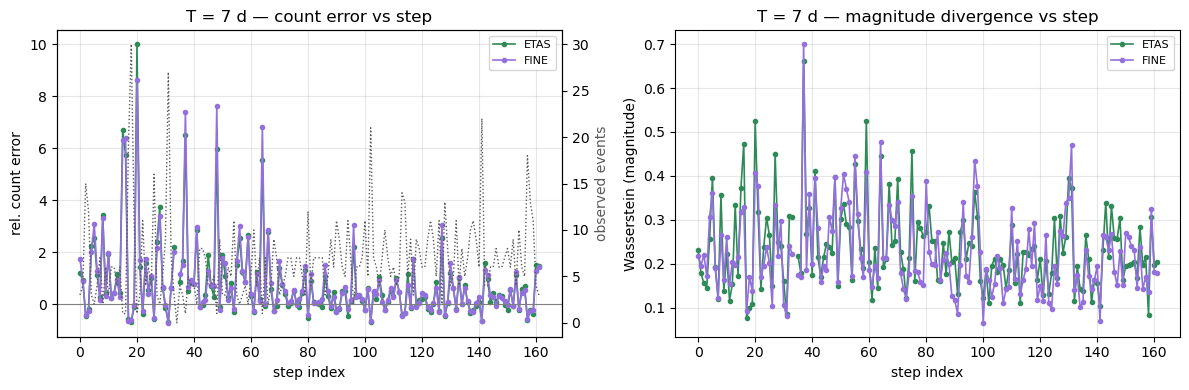

In [7]:
if metrics_df.empty:
    display(Markdown("_Skip per-step path plots — no metrics yet._"))
else:
    sub = metrics_df.sort_values("step_index")
    x = sub["step_index"].to_numpy()
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    for method in METHODS:
        col_err = f"{method}_rel_count_error"
        col_w = f"{method}_wasserstein_mag"
        color = METHOD_COLORS.get(method)
        label = METHOD_LABELS.get(method, method)
        if col_err in sub.columns and sub[col_err].notna().any():
            axes[0].plot(x, sub[col_err], marker="o", ms=3, lw=1.2, label=label, color=color)
        if col_w in sub.columns and sub[col_w].notna().any():
            axes[1].plot(x, sub[col_w], marker="o", ms=3, lw=1.2, label=label, color=color)
    if "observed_n_events" in sub.columns:
        ax0_t = axes[0].twinx()
        ax0_t.plot(x, sub["observed_n_events"], color="0.35", ls=":", lw=1.0)
        ax0_t.set_ylabel("observed events", color="0.35")
    axes[0].axhline(0, color="0.5", lw=0.8)
    axes[0].set_xlabel("step index")
    axes[0].set_ylabel("rel. count error")
    axes[0].set_title(f"T = {HORIZON_DAYS:g} d — count error vs step")
    axes[0].legend(fontsize=8)
    axes[0].grid(True, alpha=0.3)
    axes[1].set_xlabel("step index")
    axes[1].set_ylabel("Wasserstein (magnitude)")
    axes[1].set_title(f"T = {HORIZON_DAYS:g} d — magnitude divergence vs step")
    axes[1].legend(fontsize=8)
    axes[1].grid(True, alpha=0.3)
    fig.tight_layout()
    show_fig(fig)


## Tier 1 — concatenated forecast trajectory

Per-step forecasts are stitched in time order. Plots use **Plotly** (drag to zoom, double-click to reset).
Delicate vertical lines mark rolling forecast window starts; a dashed line marks progress so far when the run is incomplete.
Observed (true) events cover the **full configured test period**, even if forecasts have not finished yet.


In [8]:
trajectory: dict[str, Any] = {}
if HORIZON_DIR is not None and SEEDS and BASE_CFG:
    trajectory = build_concatenated_trajectory(HORIZON_DIR, METHODS, SEEDS, BASE_CFG)

if not trajectory or not any(trajectory.get("catalogs_by_method", {}).get(m) for m in METHODS):
    display(Markdown(
        "_No concatenated trajectory yet — need at least one complete step "
        "(all methods × selected seeds). Re-run as the rolling job progresses._"
    ))
else:
    catalogs_by_method = trajectory["catalogs_by_method"]
    selected_seeds = sorted(set.intersection(*(set(catalogs_by_method[m]) for m in METHODS)))
    if not selected_seeds:
        display(Markdown("_No common seeds across methods for concatenated plots._"))
    else:
        seed_forecast_days = {
            int(k): float(v)
            for k, v in (trajectory.get("seed_forecast_days") or {}).items()
        }
        seed_n_steps = {
            int(k): int(v)
            for k, v in (trajectory.get("seed_n_steps") or {}).items()
        }
        forecast_days = float(trajectory["forecast_days"])
        full_test_days = float(trajectory.get("full_test_days", forecast_days))
        train_days = float(trajectory["train_days"])
        train_dt_days = trajectory["train_dt_days"]
        actual_test_dt_days = trajectory["actual_test_dt_days"]
        window_starts_days = trajectory["window_starts_days"]
        n_steps = trajectory["n_steps_concatenated"]
        # Analysis plots stop at completed forecasts; planned full test is progress-only.
        plot_end_days = float(forecast_days)

        def _mask_after_seed_end(arr: np.ndarray, seeds: list[int], t_vals: np.ndarray) -> np.ndarray:
            """NaN each row after that seed's last completed forecast window."""
            out = np.array(arr, dtype=float, copy=True)
            for i, seed in enumerate(seeds):
                t_end = seed_forecast_days.get(seed)
                if t_end is None:
                    continue
                out[i, t_vals > t_end] = np.nan
            return out

        display(Markdown(
            f"**Concatenated trajectory:** up to {n_steps} steps, "
            f"forecast progress {forecast_days:.1f} / {full_test_days:.1f} planned test days, "
            f"**{len(selected_seeds)} realizations** {selected_seeds}"
        ))
        if seed_n_steps:
            n_txt = ", ".join(
                f"seed {s}: {seed_n_steps[s]} steps"
                for s in selected_seeds if s in seed_n_steps
            )
            display(Markdown(f"Per-seed coverage: {n_txt}"))
        display(Markdown(
            f"Observed used in plots (completed span): `{trajectory['global_origin']}` → `{trajectory['last_forecast_end']}`  "
            f"(n={len(actual_test_dt_days)})  \n"
            f"Planned full test (config): `{trajectory['global_origin']}` → `{trajectory.get('full_test_end', trajectory['last_forecast_end'])}`"
        ))

        try:
            import plotly.graph_objects as go
            from IPython.display import HTML
            _HAS_PLOTLY = True
        except ImportError as exc:
            _HAS_PLOTLY = False
            display(Markdown(
                f"_Plotly not available ({exc}). Install with `pip install plotly` "
                "in the notebook env._"
            ))

        if _HAS_PLOTLY:
            n_grid = max(300, int(plot_end_days) + 50)
            t_grid = np.linspace(-train_days, plot_end_days, n_grid)
            forecast_mask = t_grid >= 0.0

            curves_by_method = {}
            for method in METHODS:
                if not all(s in catalogs_by_method[method] for s in selected_seeds):
                    continue
                arr = np.vstack([
                    cumulative_on_grid(
                        catalogs_by_method[method][s]["dt_days"].to_numpy(dtype=float),
                        t_grid,
                    )
                    for s in selected_seeds
                ])
                curves_by_method[method] = _mask_after_seed_end(arr, selected_seeds, t_grid)
            slopes_by_method = {}
            for method, arr in curves_by_method.items():
                mean_y = np.nanmean(arr, axis=0)
                fit_mask = forecast_mask & np.isfinite(mean_y)
                if np.sum(fit_mask) >= 2:
                    slopes_by_method[method] = float(
                        np.polyfit(t_grid[fit_mask], mean_y[fit_mask], 1)[0]
                    )
                else:
                    slopes_by_method[method] = 0.0

            def _plotly_window_shapes(x_end: float) -> list[dict]:
                shapes = [
                    dict(
                        type="line",
                        x0=0.0,
                        x1=0.0,
                        y0=0,
                        y1=1,
                        yref="paper",
                        line=dict(color="gray", width=1, dash="dot"),
                    )
                ]
                for x in window_starts_days:
                    if 0.0 < float(x) <= x_end:
                        shapes.append(
                            dict(
                                type="line",
                                x0=float(x),
                                x1=float(x),
                                y0=0,
                                y1=1,
                                yref="paper",
                                line=dict(color="rgba(160,160,160,0.55)", width=0.7),
                            )
                        )
                if forecast_days < full_test_days - 1e-6:
                    shapes.append(
                        dict(
                            type="line",
                            x0=forecast_days,
                            x1=forecast_days,
                            y0=0,
                            y1=1,
                            yref="paper",
                            line=dict(color="rgba(80,80,80,0.85)", width=1.2, dash="dash"),
                        )
                    )
                return shapes

            # ---- Cumulative (Plotly) ----
            fig_cum = go.Figure()
            if train_dt_days is not None and np.size(train_dt_days):
                train_curve = cumulative_on_grid(
                    np.asarray(train_dt_days, dtype=float), t_grid
                )
                train_mask = t_grid <= 0.0
                fig_cum.add_trace(
                    go.Scatter(
                        x=t_grid[train_mask],
                        y=train_curve[train_mask],
                        mode="lines",
                        name=f"Training (n={np.size(train_dt_days)})",
                        line=dict(color="black", width=2, dash="dash"),
                    )
                )

            for method, arr in curves_by_method.items():
                color = METHOD_COLORS.get(method, "gray")
                label = METHOD_LABELS.get(method, method)
                slope = slopes_by_method.get(method, 0.0)
                n_real = arr.shape[0]
                for i, seed in enumerate(selected_seeds):
                    fig_cum.add_trace(
                        go.Scatter(
                            x=t_grid[forecast_mask],
                            y=arr[i, forecast_mask],
                            mode="lines",
                            name=f"{label} realizations" if i == 0 else None,
                            legendgroup=f"{method}-real",
                            showlegend=(i == 0),
                            line=dict(color=color, width=0.8),
                            opacity=0.55,
                            hovertemplate=(
                                f"{label} seed {seed}<br>"
                                "t=%{x:.1f} d<br>N=%{y:.0f}<extra></extra>"
                            ),
                        )
                    )
                mean = np.nanmean(arr, axis=0)
                median = np.nanmedian(arr, axis=0)
                fig_cum.add_trace(
                    go.Scatter(
                        x=t_grid[forecast_mask],
                        y=mean[forecast_mask],
                        mode="lines",
                        name=f"{label} mean ({slope:.3f} /day, n={n_real})",
                        legendgroup=method,
                        line=dict(color=color, width=2.6),
                    )
                )
                fig_cum.add_trace(
                    go.Scatter(
                        x=t_grid[forecast_mask],
                        y=median[forecast_mask],
                        mode="lines",
                        name=f"{label} median",
                        legendgroup=method,
                        line=dict(color=color, width=2.0, dash="dot"),
                    )
                )

            if actual_test_dt_days.size:
                obs_curve = cumulative_on_grid(
                    np.asarray(actual_test_dt_days, dtype=float), t_grid
                )
                obs_mask = t_grid >= 0.0
                fig_cum.add_trace(
                    go.Scatter(
                        x=t_grid[obs_mask],
                        y=obs_curve[obs_mask],
                        mode="lines",
                        name=f"Actual test catalog (n={actual_test_dt_days.size})",
                        line=dict(color="black", width=2.2),
                    )
                )

            fig_cum.update_layout(
                title=(
                    f"Cumulative event count — T={HORIZON_DAYS:g}d walk-forward "
                    f"({n_steps} windows stitched)"
                ),
                xaxis_title="days since first forecast start",
                yaxis_title="cumulative number of events N(t)",
                height=520,
                legend=dict(x=0.01, y=0.99, xanchor="left", yanchor="top"),
                shapes=_plotly_window_shapes(plot_end_days),
                dragmode="zoom",
                template="plotly_white",
                margin=dict(t=60),
            )
            fig_cum.update_xaxes(range=[-train_days, plot_end_days * 1.01])
            display(Markdown(
                "**Interactive Plotly** — drag to box-zoom, double-click to reset. "
                "Gray lines = window starts; dashed gray = forecast progress so far "
                "(if incomplete)."
            ))
            display(HTML(fig_cum.to_html(include_plotlyjs="cdn", full_html=False)))

            # ---- Rate by bin (Plotly) ----
            t_min, t_max = -train_days, plot_end_days
            negative_edges = -np.arange(0.0, train_days + BIN_LENGTH_DAYS, BIN_LENGTH_DAYS)[::-1]
            negative_edges = negative_edges[negative_edges >= t_min]
            if negative_edges.size == 0 or negative_edges[0] > t_min:
                negative_edges = np.insert(negative_edges, 0, t_min)
            positive_edges = np.arange(0.0, plot_end_days + BIN_LENGTH_DAYS, BIN_LENGTH_DAYS)
            positive_edges = positive_edges[positive_edges <= t_max]
            if positive_edges.size == 0 or positive_edges[-1] < t_max:
                positive_edges = np.append(positive_edges, t_max)
            bin_edges = np.unique(np.concatenate((negative_edges, positive_edges)))
            bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
            test_bin_mask = bin_edges[:-1] >= 0.0

            bin_curves_by_method = {}
            for method in METHODS:
                if not all(s in catalogs_by_method[method] for s in selected_seeds):
                    continue
                arr = np.vstack([
                    events_per_time_bin(
                        catalogs_by_method[method][s]["dt_days"].to_numpy(dtype=float),
                        bin_edges,
                    )
                    for s in selected_seeds
                ])
                bin_curves_by_method[method] = _mask_after_seed_end(
                    arr, selected_seeds, bin_centers
                )

            fig_rate = go.Figure()
            if train_dt_days is not None and np.size(train_dt_days):
                train_bins = events_per_time_bin(
                    np.asarray(train_dt_days, dtype=float), bin_edges
                )
                neg_mask = bin_edges[1:] <= 0.0
                fig_rate.add_trace(
                    go.Scatter(
                        x=bin_centers[neg_mask],
                        y=train_bins[neg_mask],
                        mode="lines",
                        name="Training",
                        line=dict(color="black", width=2, dash="dash"),
                    )
                )

            for method, arr in bin_curves_by_method.items():
                color = METHOD_COLORS.get(method, "gray")
                label = METHOD_LABELS.get(method, method)
                n_real = arr.shape[0]
                for i, seed in enumerate(selected_seeds):
                    fig_rate.add_trace(
                        go.Scatter(
                            x=bin_centers[test_bin_mask],
                            y=arr[i, test_bin_mask],
                            mode="lines",
                            name=f"{label} realizations" if i == 0 else None,
                            legendgroup=f"{method}-real",
                            showlegend=(i == 0),
                            line=dict(color=color, width=0.8),
                            opacity=0.55,
                            hovertemplate=(
                                f"{label} seed {seed}<br>"
                                "t=%{x:.1f} d<br>rate=%{y:.2f}<extra></extra>"
                            ),
                        )
                    )
                mean = np.nanmean(arr, axis=0)
                median = np.nanmedian(arr, axis=0)
                fig_rate.add_trace(
                    go.Scatter(
                        x=bin_centers[test_bin_mask],
                        y=mean[test_bin_mask],
                        mode="lines",
                        name=f"{label} mean per bin (n={n_real})",
                        legendgroup=method,
                        line=dict(color=color, width=2.6),
                    )
                )
                fig_rate.add_trace(
                    go.Scatter(
                        x=bin_centers[test_bin_mask],
                        y=median[test_bin_mask],
                        mode="lines",
                        name=f"{label} median per bin",
                        legendgroup=method,
                        line=dict(color=color, width=2.0, dash="dot"),
                    )
                )

            if actual_test_dt_days.size:
                obs_bins = events_per_time_bin(
                    np.asarray(actual_test_dt_days, dtype=float), bin_edges
                )
                fig_rate.add_trace(
                    go.Scatter(
                        x=bin_centers[test_bin_mask],
                        y=obs_bins[test_bin_mask],
                        mode="lines",
                        name="Actual test catalog",
                        line=dict(color="black", width=2.2),
                    )
                )

            fig_rate.update_layout(
                title=(
                    f"Event rate by time bin ({BIN_LENGTH_DAYS:g}-day bins) — "
                    f"T={HORIZON_DAYS:g}d walk-forward"
                ),
                xaxis_title="days since first forecast start",
                yaxis_title="events per time bin",
                height=520,
                legend=dict(x=0.01, y=0.99, xanchor="left", yanchor="top"),
                shapes=_plotly_window_shapes(plot_end_days),
                dragmode="zoom",
                template="plotly_white",
                margin=dict(t=60),
            )
            fig_rate.update_xaxes(range=[-train_days, plot_end_days * 1.01])
            display(HTML(fig_rate.to_html(include_plotlyjs="cdn", full_html=False)))


**Concatenated trajectory:** up to 162 steps, forecast progress 1133.0 / 1133.0 planned test days, **30 realizations** [10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39]

Per-seed coverage: seed 10: 162 steps, seed 11: 162 steps, seed 12: 162 steps, seed 13: 162 steps, seed 14: 162 steps, seed 15: 162 steps, seed 16: 162 steps, seed 17: 162 steps, seed 18: 162 steps, seed 19: 162 steps, seed 20: 162 steps, seed 21: 162 steps, seed 22: 162 steps, seed 23: 162 steps, seed 24: 162 steps, seed 25: 162 steps, seed 26: 162 steps, seed 27: 162 steps, seed 28: 162 steps, seed 29: 162 steps, seed 30: 162 steps, seed 31: 162 steps, seed 32: 162 steps, seed 33: 162 steps, seed 34: 162 steps, seed 35: 162 steps, seed 36: 162 steps, seed 37: 162 steps, seed 38: 162 steps, seed 39: 162 steps

Observed used in plots (completed span): `2016-05-23 23:05:46` → `2019-07-01 00:00:00`  (n=1088)  
Planned full test (config): `2016-05-23 23:05:46` → `2019-07-01 00:00:00`

**Interactive Plotly** — drag to box-zoom, double-click to reset. Gray lines = window starts; dashed gray = forecast progress so far (if incomplete).

## Tier 2 — interevent time and magnitude

Two views over the **full concatenated test-period catalogs**:

1. **Per realization** — thin step histograms (one line per seed), plus a thicker **median** density across seeds.
2. **All realizations combined** — filled histograms pooling every seed (same as the ensemble notebook).

The single-window deep dive below is optional and typically too sparse for a 7-day step.

**Pooled over 30 realizations** [10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39]  
`ETAS`: 38651 IETs, 38681 magnitudes  `FINE`: 39591 IETs, 39621 magnitudes  
Observed test: 1087 IETs, 1088 magnitudes

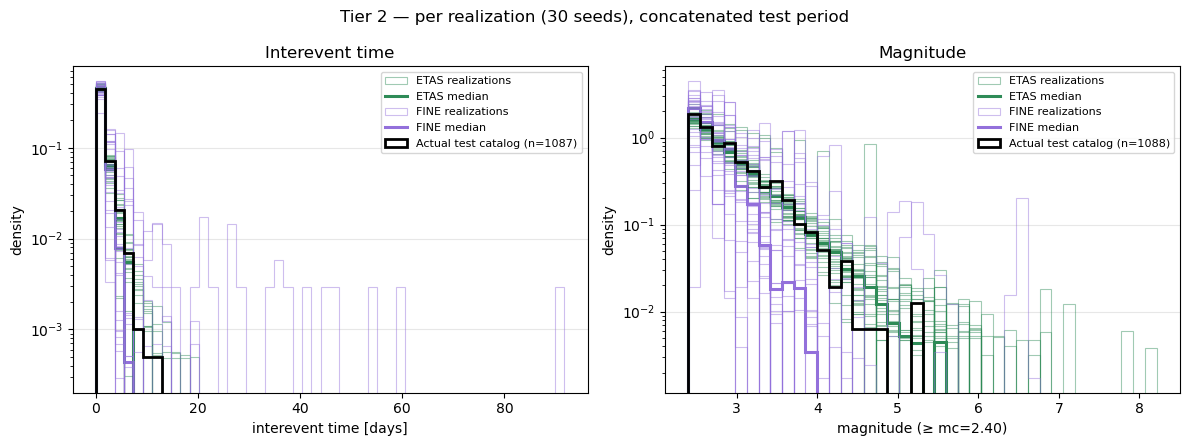

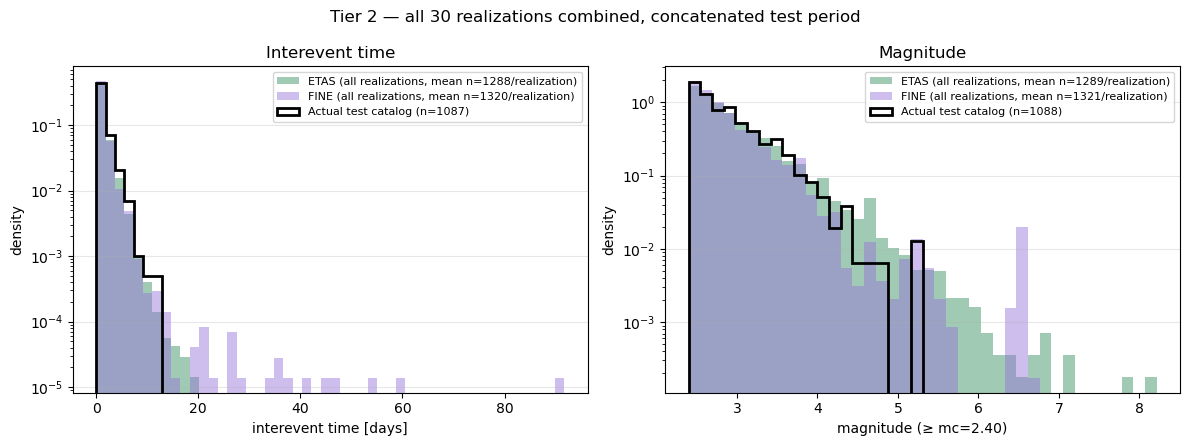

**Tier 2 — pairwise KS tests:**

,comparison,quantity,KS statistic,p-value
0,ETAS vs FINE,interevent time,0.031077,7.621514e-17
1,ETAS vs FINE,magnitude,0.081685,4.694297e-114


In [9]:
interevent_times = uf.interevent_times

if not trajectory or not any(trajectory.get("catalogs_by_method", {}).get(m) for m in METHODS):
    display(Markdown(
        "_Pooled histograms need the concatenated trajectory from the previous cell. "
        "Re-run that cell first._"
    ))
else:
    catalogs_by_method = trajectory["catalogs_by_method"]
    selected_seeds = sorted(set.intersection(*(set(catalogs_by_method[m]) for m in METHODS)))
    mc_val = float(BASE_CFG.get("mc", np.nan)) if BASE_CFG else np.nan
    actual_test_dt_days = np.asarray(trajectory.get("actual_test_dt_days", []), dtype=float)

    actual_test_m = np.array([], dtype=float)
    if BASE_CFG:
        cat_path = Path(BASE_CFG.get("fn_catalog", ""))
        if not cat_path.is_file():
            cat_path = REPO_ROOT / str(BASE_CFG.get("fn_catalog", ""))
        if cat_path.is_file() and trajectory.get("global_origin") is not None:
            raw = pd.read_csv(cat_path)
            # Match completed forecast span (same as trajectory["actual_test_dt_days"]).
            full_end = trajectory.get("last_forecast_end") or trajectory.get("full_test_end")
            obs = rolling.extract_observed_events(
                raw,
                trajectory["global_origin"],
                full_end,
                mc=float(BASE_CFG.get("mc", 3.0)),
            )
            if not obs.empty and "magnitude" in obs.columns:
                actual_test_m = obs["magnitude"].to_numpy(dtype=float)

    iet_by_method_seed = {method: {} for method in METHODS}
    mag_by_method_seed = {method: {} for method in METHODS}
    pooled_iet = {}
    pooled_m = {}
    for method in METHODS:
        catalogs = catalogs_by_method.get(method, {})
        iet_parts = []
        mag_parts = []
        for seed in selected_seeds:
            cat = catalogs.get(seed)
            if cat is None or cat.empty:
                continue
            if "dt_days" in cat.columns:
                iet = interevent_times(cat["dt_days"].to_numpy(dtype=float))
                if iet.size:
                    iet_by_method_seed[method][seed] = iet
                    iet_parts.append(iet)
            mag_col = "m" if "m" in cat.columns else ("magnitude" if "magnitude" in cat.columns else None)
            if mag_col is not None:
                mags = cat[mag_col].to_numpy(dtype=float)
                if np.isfinite(mc_val):
                    mags = mags[mags >= mc_val]
                if mags.size:
                    mag_by_method_seed[method][seed] = mags
                    mag_parts.append(mags)
        pooled_iet[method] = np.concatenate(iet_parts) if iet_parts else np.array([], dtype=float)
        pooled_m[method] = np.concatenate(mag_parts) if mag_parts else np.array([], dtype=float)

    test_iet = interevent_times(actual_test_dt_days) if actual_test_dt_days.size else np.array([], dtype=float)
    test_m = actual_test_m
    if np.isfinite(mc_val) and test_m.size:
        test_m = test_m[test_m >= mc_val]

    n_iet = {m: int(pooled_iet[m].size) for m in METHODS}
    n_mag = {m: int(pooled_m[m].size) for m in METHODS}
    display(Markdown(
        f"**Pooled over {len(selected_seeds)} realizations** {selected_seeds}  \n"
        + "  ".join(
            f"`{METHOD_LABELS.get(m, m)}`: {n_iet[m]} IETs, {n_mag[m]} magnitudes"
            for m in METHODS
        )
        + f"  \nObserved test: {test_iet.size} IETs, {test_m.size} magnitudes"
    ))

    _IET_BINS = 50
    _MAG_BINS = 40
    _TEST_HIST_KW = {
        "density": True,
        "histtype": "step",
        "linewidth": 2.0,
        "color": "black",
        "zorder": 5,
    }

    def _shared_edges(arrays, n_bins):
        parts = [a for a in arrays if a is not None and np.asarray(a).size]
        if not parts:
            return n_bins
        return np.histogram_bin_edges(np.concatenate(parts), bins=n_bins)

    iet_edges = _shared_edges(
        [pooled_iet[m] for m in METHODS] + [test_iet],
        _IET_BINS,
    )
    mag_edges = _shared_edges(
        [pooled_m[m] for m in METHODS] + [test_m],
        _MAG_BINS,
    )
    mag_xlabel = f"magnitude (≥ mc={mc_val:.2f})" if np.isfinite(mc_val) else "magnitude"

    def _median_density(by_seed: dict[int, np.ndarray], edges) -> np.ndarray | None:
        dens_rows = []
        for seed in selected_seeds:
            arr = by_seed.get(seed)
            if arr is not None and arr.size:
                dens, _ = np.histogram(arr, bins=edges, density=True)
                dens_rows.append(dens)
        if not dens_rows:
            return None
        return np.median(np.stack(dens_rows, axis=0), axis=0)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
    for method in METHODS:
        color = METHOD_COLORS.get(method)
        label = METHOD_LABELS.get(method, method)
        for i, seed in enumerate(selected_seeds):
            iet = iet_by_method_seed[method].get(seed)
            if iet is not None and iet.size:
                axes[0].hist(
                    iet,
                    bins=iet_edges,
                    density=True,
                    histtype="step",
                    linewidth=0.8,
                    alpha=0.45,
                    color=color,
                    label=f"{label} realizations" if i == 0 else None,
                )
            mags = mag_by_method_seed[method].get(seed)
            if mags is not None and mags.size:
                axes[1].hist(
                    mags,
                    bins=mag_edges,
                    density=True,
                    histtype="step",
                    linewidth=0.8,
                    alpha=0.45,
                    color=color,
                    label=f"{label} realizations" if i == 0 else None,
                )
        iet_med = _median_density(iet_by_method_seed[method], iet_edges)
        if iet_med is not None:
            axes[0].stairs(
                iet_med,
                iet_edges,
                color=color,
                linewidth=2.2,
                label=f"{label} median",
            )
        mag_med = _median_density(mag_by_method_seed[method], mag_edges)
        if mag_med is not None:
            axes[1].stairs(
                mag_med,
                mag_edges,
                color=color,
                linewidth=2.2,
                label=f"{label} median",
            )
    if test_iet.size:
        axes[0].hist(
            test_iet,
            bins=iet_edges,
            label=f"Actual test catalog (n={test_iet.size})",
            **_TEST_HIST_KW,
        )
    if test_m.size:
        axes[1].hist(
            test_m,
            bins=mag_edges,
            label=f"Actual test catalog (n={test_m.size})",
            **_TEST_HIST_KW,
        )
    axes[0].set_xlabel("interevent time [days]")
    axes[0].set_ylabel("density")
    axes[0].set_yscale("log")
    axes[0].set_title("Interevent time")
    axes[0].legend(fontsize=8, loc="upper right")
    axes[0].grid(True, alpha=0.3, axis="y")
    axes[1].set_xlabel(mag_xlabel)
    axes[1].set_ylabel("density")
    axes[1].set_yscale("log")
    axes[1].set_title("Magnitude")
    axes[1].legend(fontsize=8, loc="upper right")
    axes[1].grid(True, alpha=0.3, axis="y")
    fig.suptitle(
        f"Tier 2 — per realization ({len(selected_seeds)} seeds), concatenated test period",
        fontsize=12,
    )
    fig.tight_layout()
    show_fig(fig)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
    for method in METHODS:
        label = METHOD_LABELS.get(method, method)
        color = METHOD_COLORS.get(method)
        n_seeds_iet = len(iet_by_method_seed[method])
        n_seeds_mag = len(mag_by_method_seed[method])
        mean_n_iet = (
            pooled_iet[method].size / n_seeds_iet if n_seeds_iet else 0.0
        )
        mean_n_mag = (
            pooled_m[method].size / n_seeds_mag if n_seeds_mag else 0.0
        )
        if pooled_iet[method].size:
            axes[0].hist(
                pooled_iet[method],
                bins=iet_edges,
                density=True,
                alpha=0.45,
                color=color,
                label=f"{label} (all realizations, mean n={mean_n_iet:.0f}/realization)",
            )
        if pooled_m[method].size:
            axes[1].hist(
                pooled_m[method],
                bins=mag_edges,
                density=True,
                alpha=0.45,
                color=color,
                label=f"{label} (all realizations, mean n={mean_n_mag:.0f}/realization)",
            )
    if test_iet.size:
        axes[0].hist(
            test_iet,
            bins=iet_edges,
            label=f"Actual test catalog (n={test_iet.size})",
            **_TEST_HIST_KW,
        )
    if test_m.size:
        axes[1].hist(
            test_m,
            bins=mag_edges,
            label=f"Actual test catalog (n={test_m.size})",
            **_TEST_HIST_KW,
        )
    axes[0].set_xlabel("interevent time [days]")
    axes[0].set_ylabel("density")
    axes[0].set_title("Interevent time")
    axes[0].legend(fontsize=8, loc="upper right")
    axes[0].grid(True, alpha=0.3, axis="y")
    axes[0].set_yscale("log")
    axes[1].set_xlabel(mag_xlabel)
    axes[1].set_ylabel("density")
    axes[1].set_title("Magnitude")
    axes[1].legend(fontsize=8, loc="upper right")
    axes[1].grid(True, alpha=0.3, axis="y")
    axes[1].set_yscale("log")
    fig.suptitle(
        f"Tier 2 — all {len(selected_seeds)} realizations combined, concatenated test period",
        fontsize=12,
    )
    fig.tight_layout()
    show_fig(fig)

    if len(METHODS) >= 2:
        ks_rows = []
        for i, ma in enumerate(METHODS):
            for mb in METHODS[i + 1 :]:
                for name, store in [("interevent time", pooled_iet), ("magnitude", pooled_m)]:
                    a_data, b_data = store[ma], store[mb]
                    if a_data.size and b_data.size:
                        stat, pval = stats.ks_2samp(a_data, b_data)
                        ks_rows.append(
                            {
                                "comparison": f"{METHOD_LABELS.get(ma, ma)} vs {METHOD_LABELS.get(mb, mb)}",
                                "quantity": name,
                                "KS statistic": stat,
                                "p-value": pval,
                            }
                        )
        if ks_rows:
            display(Markdown("**Tier 2 — pairwise KS tests:**"))
            display(pd.DataFrame(ks_rows))


## Spatial distribution — test vs forecasts

Separate axes (no overlays), with Natural Earth **coastlines**, **country borders**, and **state/province** lines (cartopy 50m):

| | Scatter (size ∝ base^magnitude) | Spatial density |
|---|---|---|
| Observed test | panel | panel |
| Each method | one selected seed | all realizations pooled |

`SPATIAL_MAP_SEED` selects the scatter seed (default: first available).


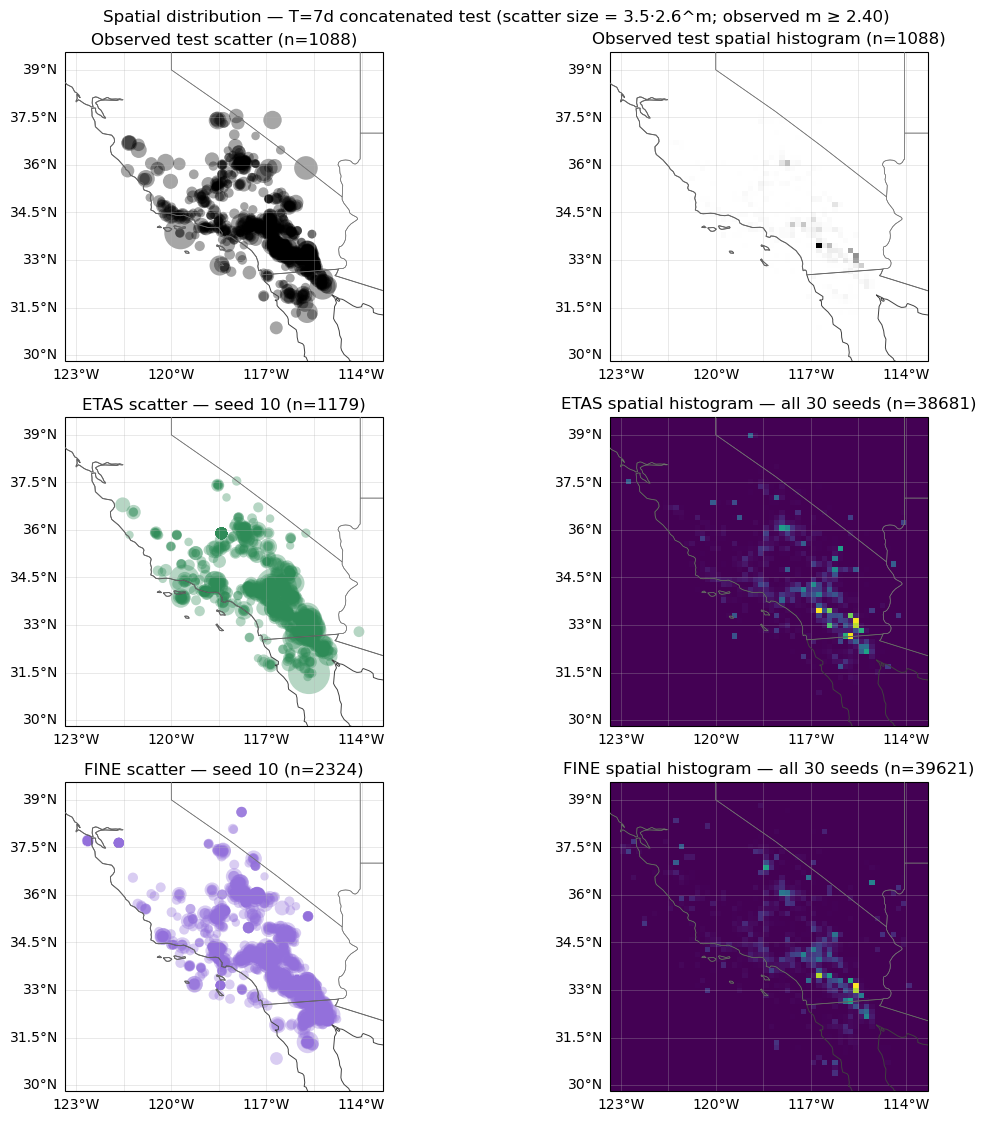

Map seed: **10**; pooled seeds: [10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39]

In [10]:
_SPATIAL_BINS = 60
_MAG_SIZE_BASE = 2.6
_MAG_SIZE_SCALE = 3.5

try:
    from cartopy import crs as ccrs
    import cartopy.feature as cfeature
    _HAS_CARTOPY = True
except ImportError as exc:
    _HAS_CARTOPY = False
    display(Markdown(f"_Cartopy unavailable ({exc}); spatial maps without borders._"))


def _mag_col(df: pd.DataFrame) -> str | None:
    if "m" in df.columns:
        return "m"
    if "magnitude" in df.columns:
        return "magnitude"
    return None


def _lon_lat_mag(df: pd.DataFrame) -> tuple[np.ndarray, np.ndarray, np.ndarray] | None:
    if df is None or df.empty:
        return None
    if "longitude" not in df.columns or "latitude" not in df.columns:
        return None
    lon = df["longitude"].to_numpy(dtype=float)
    lat = df["latitude"].to_numpy(dtype=float)
    mcol = _mag_col(df)
    mag = df[mcol].to_numpy(dtype=float) if mcol else np.full(lon.shape, 3.0)
    ok = np.isfinite(lon) & np.isfinite(lat) & np.isfinite(mag)
    if not np.any(ok):
        return None
    return lon[ok], lat[ok], mag[ok]


def _scatter_sizes(mags: np.ndarray) -> np.ndarray:
    return _MAG_SIZE_SCALE * (_MAG_SIZE_BASE ** np.asarray(mags, dtype=float))


def _add_map_borders(ax) -> None:
    """Country borders, state/province lines, and coastlines (Natural Earth 50m)."""
    if not _HAS_CARTOPY:
        return
    ax.add_feature(cfeature.COASTLINE.with_scale("50m"), linewidth=0.7, edgecolor="0.25", zorder=3)
    ax.add_feature(cfeature.BORDERS.with_scale("50m"), linewidth=0.65, edgecolor="0.3", zorder=3)
    ax.add_feature(cfeature.STATES.with_scale("50m"), linewidth=0.45, edgecolor="0.45", zorder=3)


def _plot_spatial_hist(ax, lon, lat, *, cmap: str, hist_range) -> None:
    """2D density on map axes (pcolormesh; hist2d is awkward on GeoAxes)."""
    H, xedges, yedges = np.histogram2d(
        lon, lat, bins=_SPATIAL_BINS, range=hist_range, density=True,
    )
    if _HAS_CARTOPY:
        ax.pcolormesh(
            xedges, yedges, H.T,
            cmap=cmap, shading="auto",
            transform=ccrs.PlateCarree(),
            zorder=1,
        )
    else:
        ax.pcolormesh(xedges, yedges, H.T, cmap=cmap, shading="auto", zorder=1)


if not trajectory or not any(trajectory.get("catalogs_by_method", {}).get(m) for m in METHODS):
    display(Markdown("_Spatial maps need the concatenated trajectory. Re-run that cell first._"))
else:
    catalogs_by_method = trajectory["catalogs_by_method"]
    selected_seeds = sorted(set.intersection(*(set(catalogs_by_method[m]) for m in METHODS)))
    map_seed = SPATIAL_MAP_SEED if SPATIAL_MAP_SEED in selected_seeds else (
        selected_seeds[0] if selected_seeds else None
    )
    mc_val = float(BASE_CFG.get("mc", np.nan)) if BASE_CFG else np.nan

    # Observed test catalog with coordinates
    obs_lon = obs_lat = obs_mag = np.array([], dtype=float)
    if BASE_CFG and trajectory.get("global_origin") is not None:
        cat_path = Path(BASE_CFG.get("fn_catalog", ""))
        if not cat_path.is_file():
            cat_path = REPO_ROOT / str(BASE_CFG.get("fn_catalog", ""))
        if cat_path.is_file():
            raw = pd.read_csv(cat_path)
            # Match completed forecast span used for concatenated analysis.
            full_end = trajectory.get("last_forecast_end") or trajectory.get("full_test_end")
            obs = rolling.extract_observed_events(
                raw,
                trajectory["global_origin"],
                full_end,
                mc=float(BASE_CFG.get("mc", 3.0)),
            )
            parsed = _lon_lat_mag(obs)
            if parsed is not None:
                obs_lon, obs_lat, obs_mag = parsed

    method_seed_xyz: dict[str, tuple[np.ndarray, np.ndarray, np.ndarray] | None] = {}
    method_pool_xy: dict[str, tuple[np.ndarray, np.ndarray]] = {}
    for method in METHODS:
        catalogs = catalogs_by_method.get(method, {})
        method_seed_xyz[method] = None
        if map_seed is not None and map_seed in catalogs:
            method_seed_xyz[method] = _lon_lat_mag(catalogs[map_seed])
        lon_parts: list[np.ndarray] = []
        lat_parts: list[np.ndarray] = []
        for seed in selected_seeds:
            parsed = _lon_lat_mag(catalogs.get(seed))
            if parsed is None:
                continue
            lon_parts.append(parsed[0])
            lat_parts.append(parsed[1])
        if lon_parts:
            method_pool_xy[method] = (np.concatenate(lon_parts), np.concatenate(lat_parts))
        else:
            method_pool_xy[method] = (np.array([], dtype=float), np.array([], dtype=float))

    # Shared geographic extent / bins
    all_lon = [obs_lon] + [method_pool_xy[m][0] for m in METHODS]
    all_lat = [obs_lat] + [method_pool_xy[m][1] for m in METHODS]
    lon_cat = np.concatenate([a for a in all_lon if a.size]) if any(a.size for a in all_lon) else np.array([])
    lat_cat = np.concatenate([a for a in all_lat if a.size]) if any(a.size for a in all_lat) else np.array([])

    if lon_cat.size == 0:
        display(Markdown("_No lon/lat coordinates found in observed or forecast catalogs._"))
    else:
        lon_pad = 0.05 * max(float(lon_cat.max() - lon_cat.min()), 0.5)
        lat_pad = 0.05 * max(float(lat_cat.max() - lat_cat.min()), 0.5)
        lon_range = (float(lon_cat.min()) - lon_pad, float(lon_cat.max()) + lon_pad)
        lat_range = (float(lat_cat.min()) - lat_pad, float(lat_cat.max()) + lat_pad)
        hist_range = [lon_range, lat_range]
        _scatter_kw = {"transform": ccrs.PlateCarree()} if _HAS_CARTOPY else {}

        n_rows = 1 + len(METHODS)
        subplot_kw = {"projection": ccrs.PlateCarree()} if _HAS_CARTOPY else {}
        fig, axes = plt.subplots(
            n_rows, 2, figsize=(12, 3.8 * n_rows), squeeze=False, subplot_kw=subplot_kw,
        )

        # Row 0 — observed test
        ax_s, ax_h = axes[0, 0], axes[0, 1]
        if obs_lon.size:
            ax_s.scatter(
                obs_lon, obs_lat,
                s=_scatter_sizes(obs_mag),
                c="black", alpha=0.35, linewidths=0, rasterized=True,
                zorder=2, **_scatter_kw,
            )
            _plot_spatial_hist(ax_h, obs_lon, obs_lat, cmap="Greys", hist_range=hist_range)
        ax_s.set_title(f"Observed test scatter (n={obs_lon.size})")
        ax_h.set_title(f"Observed test spatial histogram (n={obs_lon.size})")

        # Method rows
        for row_i, method in enumerate(METHODS, start=1):
            label = METHOD_LABELS.get(method, method)
            color = METHOD_COLORS.get(method) or f"C{row_i}"
            ax_s, ax_h = axes[row_i, 0], axes[row_i, 1]
            seed_xyz = method_seed_xyz.get(method)
            if seed_xyz is not None:
                lon_s, lat_s, mag_s = seed_xyz
                ax_s.scatter(
                    lon_s, lat_s,
                    s=_scatter_sizes(mag_s),
                    c=color, alpha=0.35, linewidths=0, rasterized=True,
                    zorder=2, **_scatter_kw,
                )
                ax_s.set_title(f"{label} scatter — seed {map_seed} (n={lon_s.size})")
            else:
                ax_s.set_title(f"{label} scatter — seed {map_seed} (empty)")
            lon_p, lat_p = method_pool_xy[method]
            if lon_p.size:
                _plot_spatial_hist(ax_h, lon_p, lat_p, cmap="viridis", hist_range=hist_range)
            ax_h.set_title(
                f"{label} spatial histogram — all {len(selected_seeds)} seeds "
                f"(n={lon_p.size})"
            )

        for ax in axes.ravel():
            _add_map_borders(ax)
            if _HAS_CARTOPY:
                ax.set_extent(
                    [lon_range[0], lon_range[1], lat_range[0], lat_range[1]],
                    crs=ccrs.PlateCarree(),
                )
                ax.set_xlabel("longitude")
                ax.set_ylabel("latitude")
                gl = ax.gridlines(draw_labels=True, linewidth=0.4, color="0.7", alpha=0.5)
                gl.top_labels = False
                gl.right_labels = False
            else:
                ax.set_xlim(*lon_range)
                ax.set_ylim(*lat_range)
                ax.set_xlabel("longitude")
                ax.set_ylabel("latitude")
                ax.set_aspect("equal", adjustable="box")
                ax.grid(True, alpha=0.25)

        mag_note = f"scatter size = {_MAG_SIZE_SCALE}·{_MAG_SIZE_BASE}^m"
        if np.isfinite(mc_val):
            mag_note += f"; observed m ≥ {mc_val:.2f}"
        fig.suptitle(
            f"Spatial distribution — T={HORIZON_DAYS:g}d concatenated test ({mag_note})",
            fontsize=12,
        )
        fig.tight_layout()
        show_fig(fig)
        display(Markdown(
            f"Map seed: **{map_seed}**; pooled seeds: {selected_seeds}"
        ))


## CSEP catalog tests — concatenated trajectory

Same pipeline as `compare_thinning_vs_thinning_magnet_ensemble.ipynb`, but on **stitched walk-forward catalogs** over the full forecast period.

The evaluation grid is built from the **ETAS study polygon** (`shape_coords`) at spacing `CSEP_DH` (default 0.1°) plus inversion magnitude bins — **not** the California RELM template.

Diagnostic figures **overlay ETAS and FINE** on the same axes for each metric.

For each method (ensemble of concatenated seeds) we run:

- **PL** — spatial pseudolikelihood consistency (catalog test; figure title “PL-test”)
- **L** — Poisson likelihood test (Zechar 2010, §5.2.1): joint log-likelihood of the observed space-magnitude counts given the ensemble expected rates, compared with catalogs simulated from those rates. The summary statistic γ (`Ltest_gamma`) is the fraction of simulated likelihoods ≤ the observed one. Small γ means the observation is inconsistent with the forecast.
- **N** — number test (event counts)
- **N** — number test (event counts)
- **M** — magnitude test
- **S** — spatial test
- **R (pairwise)** — Rhoades **T-test** on expected rates (PyCSEP has no catalog R-test; positive IG ⇒ first method better)
- **Molchan** — miss rate $\nu$ versus fraction of spatial cells alarmed $\tau$, ranked by expected rate. The dashed line is a spatially uniform Poisson baseline. Area skill score (ASS) is the area above the curve ($1 - \int \nu\,d\tau$); the uniform model scores 0.5. `area_below_diagonal` is ASS − 0.5 (positive when the curve drops below that baseline).

**Empty / zero-rate cells (CSEP):** Poisson PL already includes empty cells through $-\Lambda=-\sum\lambda_i$. Cells with events but $\lambda_i=0$ hit $-\infty$; stock CSEP then **drops those cells for the observed score only** and does **not** re-score simulations on the same mask — so obs and sims are not treated symmetrically.

The per-step CSEP section later is a short window and can still be sparse.


  Rounding issues found. Check if delta_m and mc_current are set correctly.


CSEP region: `study-grid-dh0.1` — 5881 spatial cells, 77 magnitude bins from **m ≥ 2.40**; observed events in region: **1088**  
Forecast window: `2016-05-23 23:05:46` → `2019-07-01 00:00:00`  
Seeds used: [10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39]

Found -inf as the observed likelihood score. Assuming event(s) occurred in undersampled region of forecast.
Recomputing with 1087.0 events after removing 1.0 events.
Found -inf as the observed likelihood score. Assuming event(s) occurred in undersampled region of forecast.
Recomputing with 1087.0 events after removing 1.0 events.
Found -inf as the observed likelihood score. Assuming event(s) occurred in undersampled region of forecast.
Recomputing with 1087.0 events after removing 1.0 events.
Found -inf as the observed likelihood score. Assuming event(s) occurred in undersampled region of forecast.
Recomputing with 1087.0 events after removing 1.0 events.


### Concatenated CSEP scores (L / N / M / S)

,method,label,variant,n_realizations,n_forecast,n_observed,L_delta1,L_delta2,L_obs_ll,Ltest_obs,...,N_delta1,N_delta2,N_pass,N_obs,M_delta1,M_delta2,M_obs,S_delta1,S_delta2,S_obs
0,etas,ETAS,ensemble (30 seeds),30,1289.2,1088.0,0.433333,0.566667,60.095090,-inf,...,0.7,0.3,True,1088.0,0.466667,0.533333,1.701210,0.233333,0.766667,-5.920475
1,FINE,FINE,ensemble (30 seeds),30,1320.5,1088.0,0.333333,0.666667,61.912565,-inf,...,0.5,0.5,True,1088.0,1.000000,0.000000,1.564823,0.200000,0.800000,-5.913997


### Consistency diagnostics — ETAS vs FINE overlapped (PL, N, M, S, L)

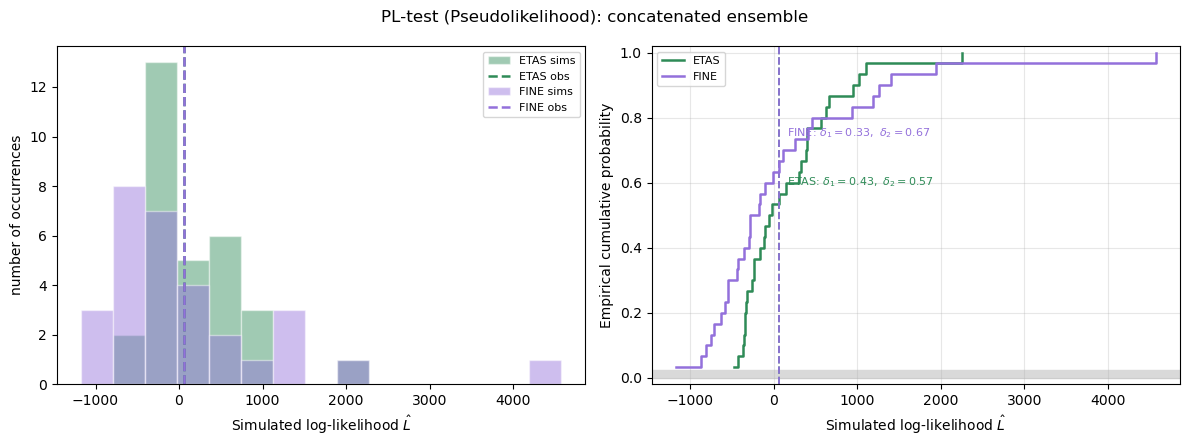

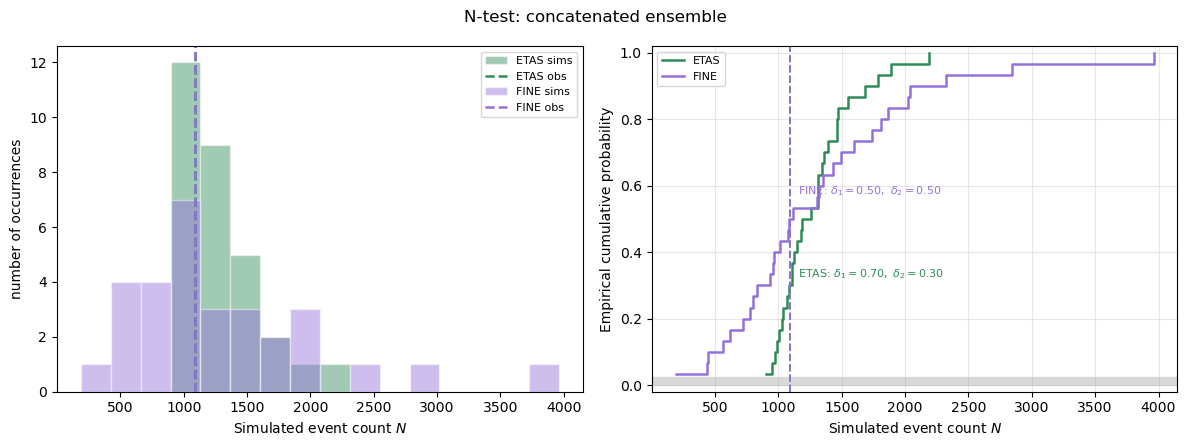

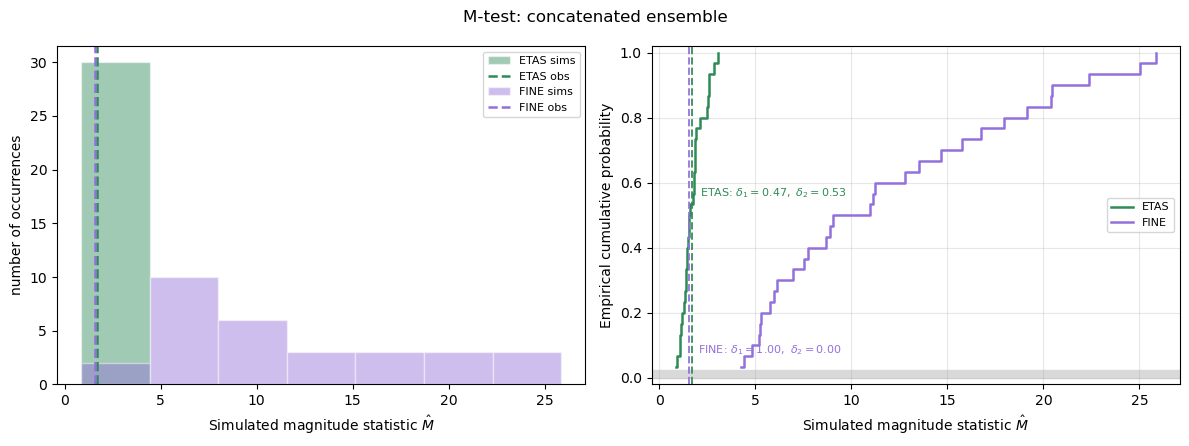

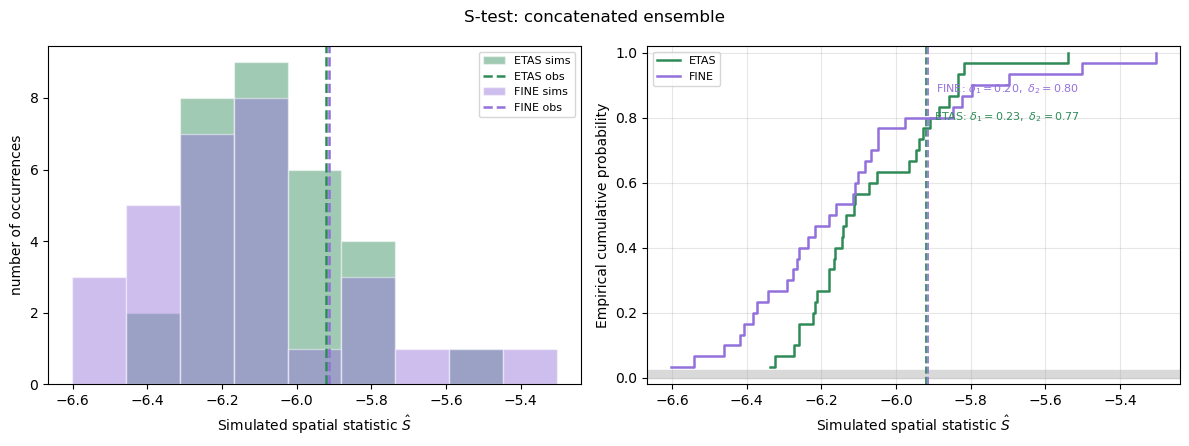

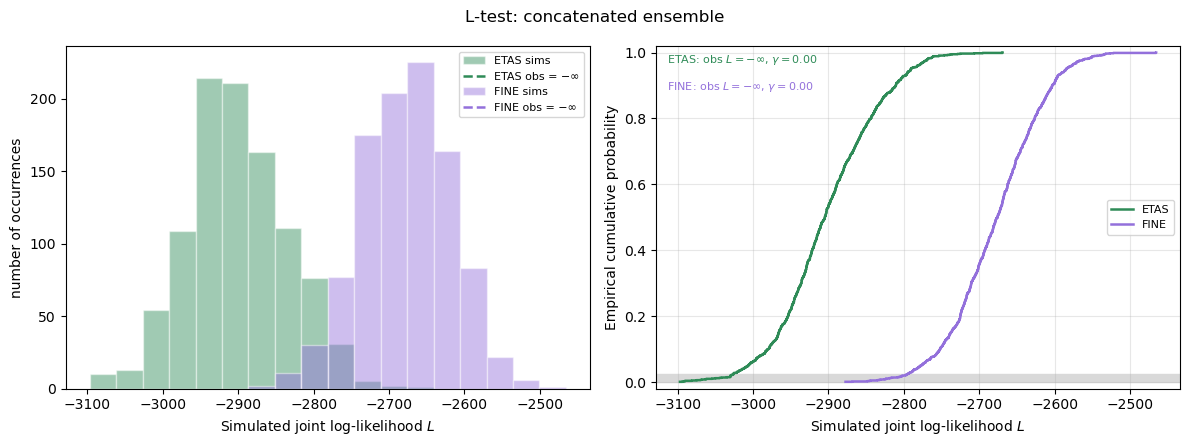

### Pairwise T-test (R-test substitute)
Positive information gain ⇒ first method outperforms second (Rhoades et al. 2011 on expected rates).

,method_a,method_b,IG_per_eq,error
0,ETAS,FINE,NaN,'NoneType' object has no attribute 'target_eve...


### Molchan diagram
Spatial cells ranked by expected rate. ASS is the area above the miss-rate curve (uniform Poisson = 0.5); `area_below_diagonal` = ASS − 0.5.

,method,ASS,area_below_diagonal,n_bins,n_target_bins
0,ETAS,0.950748,0.450748,5881,363.0
1,FINE,0.948659,0.448659,5881,363.0


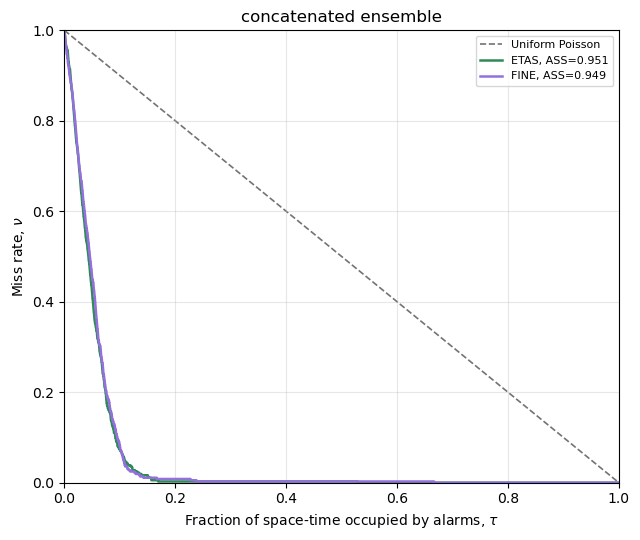

In [11]:
CSEP_LTEST_ALPHA = 0.025
CSEP_DH = 0.1  # spatial cell size (degrees) for study-polygon grid

try:
    import etas.csep_utils as csep_utils
    _HAS_CSEP_CONCAT = True
except ImportError as exc:
    _HAS_CSEP_CONCAT = False
    display(Markdown(f"_CSEP imports unavailable ({exc}). Skip concatenated CSEP tests._"))


def _find_rolling_inversion(horizon_dir: Path) -> tuple[Path | None, str | None]:
    for _step_idx, step_dir in discover_step_dirs(horizon_dir):
        inv_dirs = sorted((step_dir / "inversions").glob("inv_*"))
        if inv_dirs:
            return step_dir, inv_dirs[0].name.replace("inv_", "")
    return None, None


def _csep_scores_row(method: str, variant: str, n_cat: int, scores: dict) -> dict[str, Any]:
    keep = [
        "n_forecast", "n_observed",
        "L_delta1", "L_delta2", "L_obs_ll",
        "Ltest_obs", "Ltest_gamma",
        "N_delta1", "N_delta2", "N_pass", "N_obs",
        "M_delta1", "M_delta2", "M_obs",
        "S_delta1", "S_delta2", "S_obs",
    ]
    return {
        "method": method,
        "label": METHOD_LABELS.get(method, method),
        "variant": variant,
        "n_realizations": int(n_cat),
        **{k: scores[k] for k in keep if k in scores},
    }




if not _HAS_CSEP_CONCAT:
    pass
elif not trajectory or not any(trajectory.get("catalogs_by_method", {}).get(m) for m in METHODS):
    display(Markdown("_Concatenated CSEP tests need the trajectory cell. Re-run that first._"))
elif HORIZON_DIR is None or not BASE_CFG:
    display(Markdown("_Concatenated CSEP tests need HORIZON_DIR and BASE_CFG._"))
else:
    catalogs_by_method = trajectory["catalogs_by_method"]
    selected_seeds = sorted(set.intersection(*(set(catalogs_by_method[m]) for m in METHODS)))
    seed_days = trajectory.get("seed_forecast_days") or {}
    max_days = max((float(seed_days.get(s, 0.0)) for s in selected_seeds), default=0.0)
    pl_seeds = [s for s in selected_seeds if abs(float(seed_days.get(s, 0.0)) - max_days) <= 1e-3]
    if not pl_seeds:
        pl_seeds = selected_seeds
    inv_step_dir, inv_id = _find_rolling_inversion(HORIZON_DIR)
    if inv_step_dir is None or inv_id is None:
        display(Markdown("_No inversion directory found under this horizon — cannot build a CSEP region._"))
    elif not pl_seeds:
        display(Markdown("_No concatenated seeds available for PL-test._"))
    else:
        try:
            _, etas_inversion = csep_utils.load_inversion_for_csep(inv_step_dir, inv_id)
            m_ref = float(etas_inversion.m_ref)
            study_poly = csep_utils.etas_study_polygon_latlon(etas_inversion.shape_coords)
            csep_region = csep_utils.csep_region_from_inversion(etas_inversion, dh=CSEP_DH)

            origin = pd.to_datetime(trajectory["global_origin"], utc=True)
            end_ts = pd.to_datetime(
                trajectory.get("last_forecast_end") or trajectory.get("full_test_end"),
                utc=True,
            )
            forecast_start = origin.to_pydatetime()
            forecast_end = end_ts.to_pydatetime()
            origin_naive = origin.tz_convert(None)
            end_naive = end_ts.tz_convert(None)

            cat_path = Path(BASE_CFG.get("fn_catalog", ""))
            if not cat_path.is_file():
                cat_path = REPO_ROOT / str(BASE_CFG.get("fn_catalog", ""))
            if not cat_path.is_file():
                display(Markdown("_Observed catalog path not found for concatenated PL-test._"))
            else:
                observed_raw = pd.read_csv(cat_path)
                observed_raw["time"] = pd.to_datetime(observed_raw["time"], utc=True).dt.tz_convert(None)
                observed_raw = observed_raw.loc[
                    (observed_raw["time"] > origin_naive) & (observed_raw["time"] <= end_naive)
                ].copy()
                observed_filtered = csep_utils.filter_to_csep_region(
                    observed_raw, region=csep_region, m_ref=m_ref, study_poly=study_poly,
                )
                if observed_filtered.empty:
                    display(Markdown(
                        f"_Concatenated CSEP: **0 observed events** after filtering "
                        f"(m≥{m_ref:.2f}, study polygon ∩ evaluation grid). Skip._"
                    ))
                else:
                    observed_catalog = csep_utils.dataframe_to_csep_catalog(
                        observed_filtered, catalog_id=0, region=csep_region,
                    )
                    observed_catalog.name = "observed_test_catalog"
                    display(Markdown(
                        f"CSEP region: `{csep_region.name}` — {csep_region.num_nodes} spatial cells, "
                        f"{len(csep_region.magnitudes)} magnitude bins from **m ≥ {m_ref:.2f}**; "
                        f"observed events in region: **{observed_catalog.event_count}**  \n"
                        f"Forecast window: `{origin_naive}` → `{end_naive}`  \n"
                        f"Seeds used: {pl_seeds}"
                    ))

                    csep_rows: list[dict[str, Any]] = []
                    csep_ensemble: dict[str, dict] = {}
                    csep_forecasts: dict[str, Any] = {}
                    for method in METHODS:
                        catalogs = catalogs_by_method.get(method, {})
                        ensemble_dfs = [catalogs[s] for s in pl_seeds if s in catalogs and catalogs[s] is not None]
                        label = METHOD_LABELS.get(method, method)

                        if len(ensemble_dfs) >= 1:
                            cf_ens = csep_utils.build_catalog_forecast_from_dataframes(
                                ensemble_dfs,
                                name=f"{label} ensemble",
                                region=csep_region,
                                start_time=forecast_start,
                                end_time=forecast_end,
                                m_ref=m_ref,
                                study_poly=study_poly,
                            )
                            if cf_ens is not None:
                                scores_ens = csep_utils.run_csep_catalog_tests(
                                    cf_ens, observed_catalog, include_l_test=True,
                                )
                                sim_arrays = csep_utils.pop_csep_sim_arrays(scores_ens)
                                csep_ensemble[method] = {
                                    **scores_ens,
                                    **sim_arrays,
                                }
                                csep_forecasts[method] = cf_ens
                                csep_rows.append(_csep_scores_row(
                                    method, f"ensemble ({len(pl_seeds)} seeds)", cf_ens.n_cat, scores_ens,
                                ))

                    if csep_rows:
                        display(Markdown("### Concatenated CSEP scores (L / N / M / S)"))
                        display(pd.DataFrame(csep_rows))
                    else:
                        display(Markdown("_No CSEP scores computed (empty catalogs after filtering)._"))

                    display(Markdown("### Consistency diagnostics — ETAS vs FINE overlapped (PL, N, M, S, L)"))
                    for fig in csep_utils.plot_csep_metric_overlays(
                        csep_ensemble,
                        alpha=CSEP_LTEST_ALPHA,
                        title="concatenated ensemble",
                        colors=getattr(ce, "DEFAULT_METHOD_COLORS", {}),
                        labels=METHOD_LABELS,
                    ):
                        show_fig(fig)

                    # Pairwise T-test on expected rates (R-test substitute)
                    method_pairs = [
                        (a, b) for i, a in enumerate(METHODS) for b in METHODS[i + 1 :]
                        if a in csep_forecasts and b in csep_forecasts
                    ]
                    if method_pairs and observed_catalog.event_count > 1:
                        display(Markdown(
                            "### Pairwise T-test (R-test substitute)\n"
                            "Positive information gain ⇒ first method outperforms second "
                            "(Rhoades et al. 2011 on expected rates)."
                        ))
                        r_rows = []
                        for a, b in method_pairs:
                            try:
                                r = csep_utils.pairwise_t_test_catalog_forecasts(
                                    csep_forecasts[a], csep_forecasts[b], observed_catalog,
                                )
                                r_rows.append({
                                    "method_a": METHOD_LABELS.get(a, a),
                                    "method_b": METHOD_LABELS.get(b, b),
                                    "IG_per_eq": r["information_gain"],
                                    "IG_CI_low": r["ig_lower"],
                                    "IG_CI_high": r["ig_upper"],
                                    "t_stat": r["t_statistic"],
                                    "t_crit": r["t_critical"],
                                    "significant": r["significant"],
                                })
                            except Exception as r_exc:
                                r_rows.append({
                                    "method_a": METHOD_LABELS.get(a, a),
                                    "method_b": METHOD_LABELS.get(b, b),
                                    "IG_per_eq": np.nan,
                                    "error": str(r_exc),
                                })
                        display(pd.DataFrame(r_rows))
                    elif method_pairs:
                        display(Markdown("_Pairwise T-test skipped: need ≥2 observed events._"))

                    if csep_forecasts:
                        display(Markdown(
                            "### Molchan diagram\n"
                            "Spatial cells ranked by expected rate. "
                            "ASS is the area above the miss-rate curve "
                            "(uniform Poisson = 0.5); "
                            "`area_below_diagonal` = ASS − 0.5."
                        ))
                        molchan_table, molchan_fig = csep_utils.molchan_comparison(
                            csep_forecasts,
                            observed_catalog,
                            labels=METHOD_LABELS,
                            colors=getattr(ce, "DEFAULT_METHOD_COLORS", {}),
                            title="concatenated ensemble",
                        )
                        display(molchan_table)
                        if molchan_fig is not None:
                            show_fig(molchan_fig)
        except Exception as exc:
            display(Markdown(f"_Concatenated CSEP tests skipped: {exc}_"))


## Multi-seed formal tests (when ≥ 2 seeds complete per step)

Aggregates per-step event counts across seeds. Skipped gracefully when only seed 0 is available (`by_realization` in progress).

In [12]:
if HORIZON_DIR is None or len(SEEDS) < 2:
    display(Markdown(
        "_Formal paired tests need ≥ 2 seeds. "
        f"Currently configured: SEEDS={SEEDS}. "
        "Re-run when more realizations are on disk._"
    ))
else:
    formal_rows = []
    for step_idx, step_dir in discover_step_dirs(HORIZON_DIR):
        counts = {m: [] for m in METHODS}
        ok = True
        for seed in SEEDS:
            for m in METHODS:
                if not step_has_catalog(step_dir, m, seed):
                    ok = False
                    break
                cat = load_step_forecast_catalog(step_dir, m, seed)
                counts[m].append(len(cat) if cat is not None else 0)
            if not ok:
                break
        if not ok or len(METHODS) < 2:
            continue
        ma, mb = METHODS[0], METHODS[1]
        a = np.array(counts[ma], dtype=float)
        b = np.array(counts[mb], dtype=float)
        if len(a) >= 2 and np.any(a != b):
            w_stat, w_p = stats.wilcoxon(a, b)
        else:
            w_stat, w_p = np.nan, np.nan
        formal_rows.append({
            "step_index": step_idx,
            "test": f"Wilcoxon {METHOD_LABELS.get(ma,ma)} vs {METHOD_LABELS.get(mb,mb)}",
            "statistic": w_stat,
            "p-value": w_p,
        })
    if not formal_rows:
        display(Markdown("_No steps with all selected seeds complete for formal tests._"))
    else:
        display(pd.DataFrame(formal_rows).head(20))


,step_index,test,statistic,p-value
0,0,Wilcoxon ETAS vs FINE,156.5,0.288546
1,1,Wilcoxon ETAS vs FINE,189.0,0.749525
2,2,Wilcoxon ETAS vs FINE,170.5,0.656232
3,3,Wilcoxon ETAS vs FINE,142.5,0.401291
4,4,Wilcoxon ETAS vs FINE,138.5,0.346541
5,5,Wilcoxon ETAS vs FINE,168.0,0.283447
6,6,Wilcoxon ETAS vs FINE,207.5,0.828580
7,7,Wilcoxon ETAS vs FINE,219.5,0.788919
8,8,Wilcoxon ETAS vs FINE,194.0,0.837372
9,9,Wilcoxon ETAS vs FINE,196.5,0.649307


## MAGNET Kumaraswamy diagnostics (optional)

Requires `magnet_predictions.npz` sidecars (when `magnet.save_predictions=true`). Rolling runs often omit these.

In [13]:
import etas.magnet_inference_cache as mic

# Standalone cell — does not use the `ens` / `ce` module alias.
MAGNET_METHOD = "FINE"
MAGNET_METHOD_LEGACY = "thinning_magnet"

# Resolve optional deep-dive step (DEEP_DIVE_STEP_INDEX → latest complete for first seed).
step_dir_selected = None
step_catalogs: dict[str, pd.DataFrame] = {}
step_windows: dict[str, Any] | None = None
deep_step: int | None = None
deep_seed: int | None = SEEDS[0] if SEEDS else None

if HORIZON_DIR is not None and deep_seed is not None:
    complete_steps: list[tuple[int, Path]] = []
    for step_idx, step_dir in discover_step_dirs(HORIZON_DIR):
        if all(step_has_catalog(step_dir, m, deep_seed) for m in METHODS):
            complete_steps.append((step_idx, step_dir))
    if complete_steps:
        if DEEP_DIVE_STEP_INDEX is not None:
            matched = [(i, d) for i, d in complete_steps if i == DEEP_DIVE_STEP_INDEX]
            deep_step, step_dir_selected = matched[0] if matched else complete_steps[-1]
        else:
            deep_step, step_dir_selected = complete_steps[-1]
        step_windows = load_step_windows(step_dir_selected)
        for method in METHODS:
            cat = load_step_forecast_catalog(step_dir_selected, method, deep_seed)
            if cat is not None and not cat.empty:
                step_catalogs[method] = cat

_deep_seed = deep_seed if deep_seed is not None else 0
_step_dir = step_dir_selected

magnet_sidecars: list[Path] = []
if _step_dir is not None:
    fine_dir = Path(_step_dir) / MAGNET_METHOD
    if not fine_dir.is_dir():
        fine_dir = Path(_step_dir) / MAGNET_METHOD_LEGACY
    if fine_dir.is_dir():
        magnet_sidecars = sorted(
            fine_dir.glob(f"inv_*/seed_{_deep_seed}/" + mic._DEFAULT_SIDECAR_NAME)
        )

if not magnet_sidecars:
    display(Markdown(
        "**MAGNET prediction sidecars:** _not available_ for the deep-dive step.\n\n"
        "Enable `magnet.save_predictions: true` in the rolling config to populate "
        "`magnet_predictions.npz` per realization. Kumaraswamy PDF panels from the "
        "single-window notebook can be added here when sidecars exist."
    ))
else:
    display(Markdown(
        f"Found sidecar: `{magnet_sidecars[0]}` — extend this cell with Kumaraswamy plots as needed."
    ))
    preds = mic.load_magnet_predictions(magnet_sidecars[0])
    display(Markdown(f"Events in sidecar: **{len(preds.get('magnitude', []))}**"))


**MAGNET prediction sidecars:** _not available_ for the deep-dive step.

Enable `magnet.save_predictions: true` in the rolling config to populate `magnet_predictions.npz` per realization. Kumaraswamy PDF panels from the single-window notebook can be added here when sidecars exist.

## CSEP catalog tests (optional, per step)

One seed and one short window. Simulated-distribution overlays, the pairwise T-test, and the Molchan diagram need an ensemble of catalogs, so they are only in the concatenated section above. This cell reports the single-catalog L / N / M / S scores. The window can still be empty if few observed events fall in-grid.


In [14]:
try:
    import etas.csep_utils as csep_utils
    _HAS_CSEP = True
except ImportError as exc:
    _HAS_CSEP = False
    display(Markdown(f"_CSEP imports unavailable ({exc}). Skip this section._"))

# Resolve optional deep-dive step (DEEP_DIVE_STEP_INDEX → latest complete for first seed).
step_dir_selected = None
step_catalogs: dict[str, pd.DataFrame] = {}
step_windows: dict[str, Any] | None = None
deep_step: int | None = None
deep_seed: int | None = SEEDS[0] if SEEDS else None

if HORIZON_DIR is not None and deep_seed is not None:
    complete_steps: list[tuple[int, Path]] = []
    for step_idx, step_dir in discover_step_dirs(HORIZON_DIR):
        if all(step_has_catalog(step_dir, m, deep_seed) for m in METHODS):
            complete_steps.append((step_idx, step_dir))
    if complete_steps:
        if DEEP_DIVE_STEP_INDEX is not None:
            matched = [(i, d) for i, d in complete_steps if i == DEEP_DIVE_STEP_INDEX]
            deep_step, step_dir_selected = matched[0] if matched else complete_steps[-1]
        else:
            deep_step, step_dir_selected = complete_steps[-1]
        step_windows = load_step_windows(step_dir_selected)
        for method in METHODS:
            cat = load_step_forecast_catalog(step_dir_selected, method, deep_seed)
            if cat is not None and not cat.empty:
                step_catalogs[method] = cat

if _HAS_CSEP and step_dir_selected is not None and step_catalogs and step_windows:
    inv_root = step_dir_selected / "inversions"
    inv_dirs = sorted(inv_root.glob("inv_*"))
    if not inv_dirs:
        display(Markdown("_No inversion directory for CSEP on this step._"))
    else:
        inv_id = inv_dirs[0].name.replace("inv_", "")
        try:
            _, etas_inversion = csep_utils.load_inversion_for_csep(step_dir_selected, inv_id)
            m_ref = float(etas_inversion.m_ref)
            study_poly = csep_utils.etas_study_polygon_latlon(etas_inversion.shape_coords)
            csep_region = csep_utils.csep_region_from_inversion(etas_inversion, dh=CSEP_DH)
            f_start = pd.to_datetime(step_windows["forecast_start"], utc=True).to_pydatetime()
            f_end = pd.to_datetime(step_windows["forecast_end"], utc=True).to_pydatetime()

            cat_path = Path(BASE_CFG["fn_catalog"]) if BASE_CFG else None
            if cat_path and not cat_path.is_file():
                cat_path = REPO_ROOT / BASE_CFG["fn_catalog"]
            if cat_path and cat_path.is_file():
                observed_raw = pd.read_csv(cat_path)
                observed_raw["time"] = pd.to_datetime(observed_raw["time"], utc=True).dt.tz_convert(None)
                fs = pd.to_datetime(step_windows["forecast_start"], utc=True).tz_convert(None)
                fe = pd.to_datetime(step_windows["forecast_end"], utc=True).tz_convert(None)
                observed_raw = observed_raw.loc[(observed_raw["time"] > fs) & (observed_raw["time"] <= fe)]
                observed_filtered = csep_utils.filter_to_csep_region(
                    observed_raw, region=csep_region, m_ref=m_ref, study_poly=study_poly,
                )
                if observed_filtered.empty:
                    display(Markdown(
                        f"_CSEP: **0 observed events** in region after filtering "
                        f"(step {deep_step}, m≥{m_ref:.2f}, study polygon ∩ evaluation grid). "
                        f"N/M/S/L need target events — skip this window._"
                    ))
                else:
                    observed_catalog = csep_utils.dataframe_to_csep_catalog(
                        observed_filtered, catalog_id=0, region=csep_region,
                    )
                    csep_rows = []
                    for method, cat in step_catalogs.items():
                        cf = csep_utils.build_catalog_forecast_from_dataframes(
                            [cat], name=METHOD_LABELS.get(method, method),
                            region=csep_region, start_time=f_start, end_time=f_end,
                            m_ref=m_ref, study_poly=study_poly,
                        )
                        if cf is None:
                            continue
                        scores = csep_utils.run_csep_catalog_tests(cf, observed_catalog)
                        csep_utils.pop_csep_sim_arrays(scores)
                        csep_rows.append({"method": method, **scores})
                    if csep_rows:
                        display(Markdown(f"### CSEP scores (L/N/M/S) — step {deep_step}, T={HORIZON_DAYS:g}d"))
                        display(pd.DataFrame(csep_rows))
                    else:
                        display(Markdown("_CSEP: empty forecast catalogs after filtering._"))
            else:
                display(Markdown("_Observed catalog path not found for CSEP._"))
        except Exception as exc:
            display(Markdown(f"_CSEP evaluation skipped: {exc}_"))
elif _HAS_CSEP:
    display(Markdown("_CSEP: waiting for a complete deep-dive step._"))


  Rounding issues found. Check if delta_m and mc_current are set correctly.


Found -inf as the observed likelihood score. Assuming event(s) occurred in undersampled region of forecast.
Recomputing with 0.0 events after removing 3.0 events.
Skipping pseudo-likelihood based tests for because no events in observed catalog after correcting for under-sampling in forecast.


_CSEP evaluation skipped: pseudolikelihood_test returned None (empty or invalid observed catalog)_

## Pending artifacts checklist

Re-run the notebook as the rolling job advances; sections above auto-populate.

In [15]:
pending_rows = []
if HORIZON_DIR is not None:
    n_expected = expected_steps_for_horizon(HORIZON_DAYS, BASE_CFG)
    n_summary = sum(1 for sd in HORIZON_DIR.glob("step_*/step_summary.json"))
    pending_rows.extend([
        {"item": f"T={HORIZON_DAYS:g}d step_summary.json", "status": f"{n_summary}/{n_expected}", "note": "by_realization: after all seeds finish horizon"},
        {"item": f"T={HORIZON_DAYS:g}d rolling_summary.csv", "status": status_badge((HORIZON_DIR / "rolling_summary.csv").is_file()), "note": "end of horizon"},
        {"item": f"T={HORIZON_DAYS:g}d horizon_summary.json", "status": status_badge((HORIZON_DIR / "horizon_summary.json").is_file()), "note": "end of horizon"},
    ])
    pending_rows.append({
        "item": "MAGNET Kumaraswamy panels",
        "status": status_badge(bool(globals().get('magnet_sidecars'))),
        "note": "needs magnet.save_predictions + sidecars",
    })
    pending_rows.append({
        "item": "Multi-seed formal tests",
        "status": status_badge(len(SEEDS) >= 2 if SEEDS else False),
        "note": f"SEEDS={SEEDS}",
    })

if pending_rows:
    display(Markdown("### What is still pending vs available"))
    display(pd.DataFrame(pending_rows))
else:
    display(Markdown("_Configure `ROLLING_OUTPUT_ROOT` / `HORIZON_DAYS` and re-run._"))


### What is still pending vs available

,item,status,note
0,T=7d step_summary.json,162/162,by_realization: after all seeds finish horizon
1,T=7d rolling_summary.csv,yes,end of horizon
2,T=7d horizon_summary.json,yes,end of horizon
3,MAGNET Kumaraswamy panels,pending,needs magnet.save_predictions + sidecars
4,Multi-seed formal tests,yes,"SEEDS=[10, 11, 12, 13, 14, 15, 16, 17, 18, 19,..."
